In [1]:
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, TrainingArguments, Trainer
from peft import LoraConfig, get_peft_model, TaskType


In [2]:
# 1. Load your JSONL dataset
dataset = load_dataset("json", data_files="train_pocket_only.jsonl", split="train")
dataset = dataset.train_test_split(test_size=0.1) # 10% for evaluation

In [3]:
# 2. Initialize Model & Tokenizer (MolT5 is optimized for chemistry)
model_id = "laituan245/molt5-base-smiles2caption" # Or molt5-small for faster training
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForSeq2SeqLM.from_pretrained(model_id)

/home/cup/anaconda3/envs/lora_env/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [4]:
# 3. Apply LoRA (Low-Rank Adaptation) for "Good Performance" on limited VRAM
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q", "v"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.SEQ_2_SEQ_LM
)
model = get_peft_model(model, lora_config)

In [5]:
 #4. Preprocessing function
def preprocess_function(examples):
    # Ensure all inputs are strings and not empty
    inputs = [str(ex) if ex else "empty" for ex in examples["input"]]
    targets = [str(ex) if ex else "C" for ex in examples["output"]] # Default to Carbon if empty

    model_inputs = tokenizer(inputs, max_length=512, truncation=True, padding="max_length")
    labels = tokenizer(text_target=targets, max_length=128, truncation=True, padding="max_length")

    # CRITICAL: Replace padding with -100 so it's ignored by the loss function
    labels_with_ignore_index = []
    for label_example in labels["input_ids"]:
        labels_with_ignore_index.append([l if l != tokenizer.pad_token_id else -100 for l in label_example])

    model_inputs["labels"] = labels_with_ignore_index
    return model_inputs

tokenized_dataset = dataset.map(preprocess_function, batched=True)


Map:   0%|          | 0/6813 [00:00<?, ? examples/s]

Map:   0%|          | 0/758 [00:00<?, ? examples/s]

In [6]:
# Updated Training Arguments
training_args = TrainingArguments(
    output_dir="./molt5-ligand-gen_50_epoch",
    per_device_train_batch_size=4,   # Reduced batch size for stability
    gradient_accumulation_steps=4,  # Keeps effective batch size at 16
    num_train_epochs=50,
    eval_strategy="epoch",
    learning_rate=1e-4,             # Standard stable rate for LoRA
    weight_decay=0.01,
    max_grad_norm=1.0,              # CRITICAL: Prevents NaNs
    fp16=False,                     # DISABLE FP16 if you keep getting NaN
    logging_steps=5,
    remove_unused_columns=False     # Ensures 'labels' aren't accidentally dropped
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
)

In [9]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.833000,0.682732
2,0.842700,0.684346
3,0.827000,0.683630
4,0.772000,0.682393
5,0.853400,0.682149
6,0.796800,0.682457
7,0.788400,0.680264
8,0.765000,0.680734
9,0.745200,0.678146
10,0.788300,0.678548


'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /laituan245/molt5-base-smiles2caption/resolve/main/config.json (Caused by NameResolutionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to resolve \'huggingface.co\' ([Errno -3] Temporary failure in name resolution)"))'), '(Request ID: 21ede982-5fb5-4d31-babe-f3218b121254)')' thrown while requesting HEAD https://huggingface.co/laituan245/molt5-base-smiles2caption/resolve/main/config.json
Retrying in 1s [Retry 1/5].
'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /laituan245/molt5-base-smiles2caption/resolve/main/config.json (Caused by NameResolutionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to resolve \'huggingface.co\' ([Errno -3] Temporary failure in name resolution)"))'), '(Request ID: 30831beb-b353-466f-be6a-2024926badc2)')' thrown while requesting HEAD https://huggingface.co/laituan2

'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /laituan245/molt5-base-smiles2caption/resolve/main/config.json (Caused by NameResolutionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to resolve \'huggingface.co\' ([Errno -3] Temporary failure in name resolution)"))'), '(Request ID: 893a37c4-9bdb-4e0c-a184-f6732459bc72)')' thrown while requesting HEAD https://huggingface.co/laituan245/molt5-base-smiles2caption/resolve/main/config.json
Retrying in 1s [Retry 1/5].
'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /laituan245/molt5-base-smiles2caption/resolve/main/config.json (Caused by NameResolutionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to resolve \'huggingface.co\' ([Errno -3] Temporary failure in name resolution)"))'), '(Request ID: 78af89c5-5b96-4dd3-8e60-38b9627913a9)')' thrown while requesting HEAD https://huggingface.co/laituan2

'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /laituan245/molt5-base-smiles2caption/resolve/main/config.json (Caused by NameResolutionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to resolve \'huggingface.co\' ([Errno -3] Temporary failure in name resolution)"))'), '(Request ID: be2c4aba-092b-48e1-b05d-946670945627)')' thrown while requesting HEAD https://huggingface.co/laituan245/molt5-base-smiles2caption/resolve/main/config.json
Retrying in 1s [Retry 1/5].
'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /laituan245/molt5-base-smiles2caption/resolve/main/config.json (Caused by NameResolutionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to resolve \'huggingface.co\' ([Errno -3] Temporary failure in name resolution)"))'), '(Request ID: b4b03dd0-170e-4ca3-8641-03d809265bb2)')' thrown while requesting HEAD https://huggingface.co/laituan2

'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /laituan245/molt5-base-smiles2caption/resolve/main/config.json (Caused by NameResolutionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to resolve \'huggingface.co\' ([Errno -3] Temporary failure in name resolution)"))'), '(Request ID: 1ab1ced8-2172-4b58-babc-b09a5059b800)')' thrown while requesting HEAD https://huggingface.co/laituan245/molt5-base-smiles2caption/resolve/main/config.json
Retrying in 1s [Retry 1/5].
'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /laituan245/molt5-base-smiles2caption/resolve/main/config.json (Caused by NameResolutionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to resolve \'huggingface.co\' ([Errno -3] Temporary failure in name resolution)"))'), '(Request ID: 92d43c42-b741-4b67-8ee3-6d2e1da2fe01)')' thrown while requesting HEAD https://huggingface.co/laituan2

TrainOutput(global_step=21300, training_loss=0.7819084383400393, metrics={'train_runtime': 27737.2559, 'train_samples_per_second': 12.281, 'train_steps_per_second': 0.768, 'total_flos': 2.351143035076608e+17, 'train_loss': 0.7819084383400393, 'epoch': 50.0})

In [11]:
trainer.train(resume_from_checkpoint=True)

/home/cup/anaconda3/envs/lora_env/lib/python3.10/site-packages/transformers/trainer.py:3098: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(os.path.join(checkpoint

Epoch,Training Loss,Validation Loss


TrainOutput(global_step=21300, training_loss=0.0, metrics={'train_runtime': 0.0152, 'train_samples_per_second': 22473373.352, 'train_steps_per_second': 1405204.322, 'total_flos': 2.351143035076608e+17, 'train_loss': 0.0, 'epoch': 50.0})

In [ ]:
#visualization

In [45]:
import os

output_dir = "molt5-ligand-gen_50_epoch"

checkpoints = [d for d in os.listdir(output_dir) if d.startswith("checkpoint")]

# Sort by step number
checkpoints = sorted(checkpoints, key=lambda x: int(x.split("-")[-1]))

latest_checkpoint = checkpoints[-1]

print("Latest checkpoint:", latest_checkpoint)

Latest checkpoint: checkpoint-21300


In [46]:
import json

log_path = os.path.join(output_dir, latest_checkpoint, "trainer_state.json")

with open(log_path, "r") as f:
    logs = json.load(f)

print("Loaded logs")

Loaded logs


In [51]:
import json

log_path = "molt5-ligand-gen_50_epoch/checkpoint-1000/trainer_state.json"

with open(log_path, "r") as f:
    logs = json.load(f)

print("Logs loaded successfully")

Logs loaded successfully


In [52]:
train_loss = []
eval_loss = []
steps = []

for entry in logs["log_history"]:
    if "loss" in entry:
        train_loss.append(entry["loss"])
        steps.append(entry["step"])

    if "eval_loss" in entry:
        eval_loss.append(entry["eval_loss"])

print("Train points:", len(train_loss))
print("Eval points:", len(eval_loss))

Train points: 200
Eval points: 2


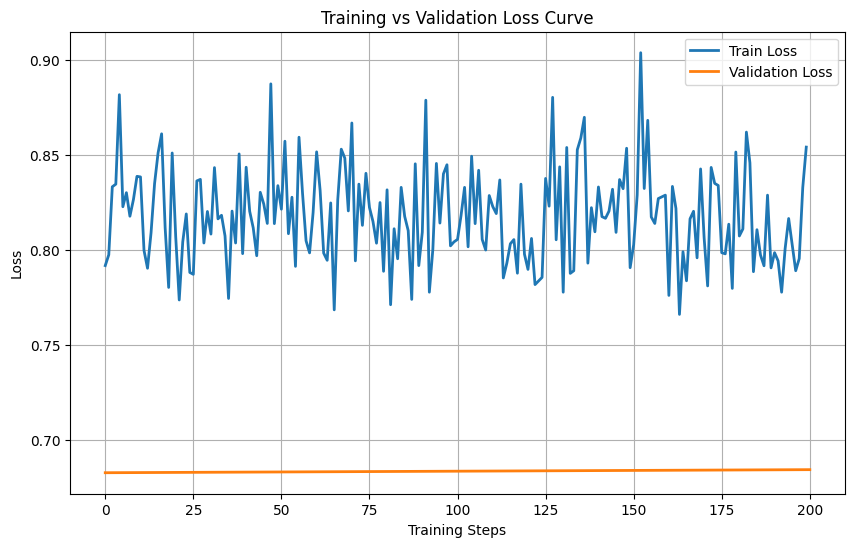

In [54]:
plt.figure(figsize=(10,6))

plt.plot(train_loss, label="Train Loss", linewidth=2)
plt.plot(eval_x, eval_loss, label="Validation Loss", linewidth=2)

plt.title("Training vs Validation Loss Curve")
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.savefig("loss_curve.png", dpi=300)
plt.show()

In [55]:
import os
import json

output_dir = "molt5-ligand-gen_50_epoch"

# Get all checkpoints
checkpoints = [d for d in os.listdir(output_dir) if d.startswith("checkpoint")]

# Sort properly
checkpoints = sorted(checkpoints, key=lambda x: int(x.split("-")[-1]))

print("Checkpoints:", checkpoints)

Checkpoints: ['checkpoint-500', 'checkpoint-1000', 'checkpoint-1500', 'checkpoint-2000', 'checkpoint-2500', 'checkpoint-3000', 'checkpoint-3500', 'checkpoint-4000', 'checkpoint-4500', 'checkpoint-5000', 'checkpoint-5500', 'checkpoint-6000', 'checkpoint-6500', 'checkpoint-7000', 'checkpoint-7500', 'checkpoint-8000', 'checkpoint-8500', 'checkpoint-9000', 'checkpoint-9500', 'checkpoint-10000', 'checkpoint-10500', 'checkpoint-11000', 'checkpoint-11500', 'checkpoint-12000', 'checkpoint-12500', 'checkpoint-13000', 'checkpoint-13500', 'checkpoint-14000', 'checkpoint-14500', 'checkpoint-15000', 'checkpoint-15500', 'checkpoint-16000', 'checkpoint-16500', 'checkpoint-17000', 'checkpoint-17500', 'checkpoint-18000', 'checkpoint-18500', 'checkpoint-19000', 'checkpoint-19500', 'checkpoint-20000', 'checkpoint-20500', 'checkpoint-21000', 'checkpoint-21300']


In [56]:
all_logs = []

for ckpt in checkpoints:
    path = os.path.join(output_dir, ckpt, "trainer_state.json")
    
    if os.path.exists(path):
        with open(path, "r") as f:
            data = json.load(f)
            all_logs.extend(data["log_history"])

In [57]:
# Remove duplicate steps
unique_logs = {}
for entry in all_logs:
    if "step" in entry:
        unique_logs[entry["step"]] = entry

logs = list(unique_logs.values())

# Sort by step
logs = sorted(logs, key=lambda x: x.get("step", 0))

In [58]:
train_loss = []
eval_loss = []
steps = []
eval_steps = []

for entry in logs:
    if "loss" in entry:
        train_loss.append(entry["loss"])
        steps.append(entry["step"])

    if "eval_loss" in entry:
        eval_loss.append(entry["eval_loss"])
        eval_steps.append(entry["step"])

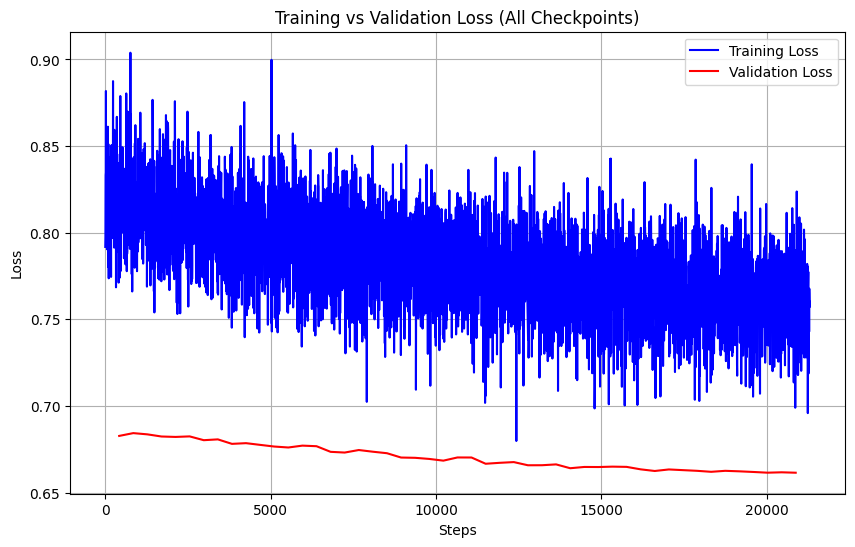

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(steps, train_loss, label="Training Loss", color="blue")

if len(eval_loss) > 0:
    plt.plot(eval_steps, eval_loss, label="Validation Loss", color="red")

plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (All Checkpoints)")
plt.legend()
plt.grid(True)

plt.show()

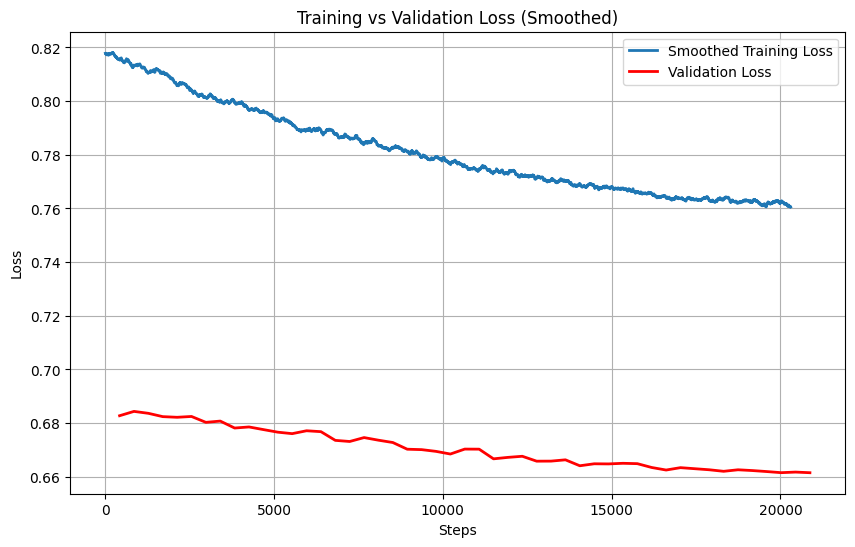

In [61]:
import numpy as np
import matplotlib.pyplot as plt

def smooth_curve(values, window=100):
    return np.convolve(values, np.ones(window)/window, mode='valid')

# Smooth training loss
smooth_train = smooth_curve(train_loss, window=200)

# Adjust steps
smooth_steps = steps[:len(smooth_train)]

plt.figure(figsize=(10,6))

plt.plot(smooth_steps, smooth_train, label="Smoothed Training Loss", linewidth=2)
plt.plot(eval_steps, eval_loss, label="Validation Loss", linewidth=2, color="red")

plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Smoothed)")
plt.legend()
plt.grid(True)

plt.show()

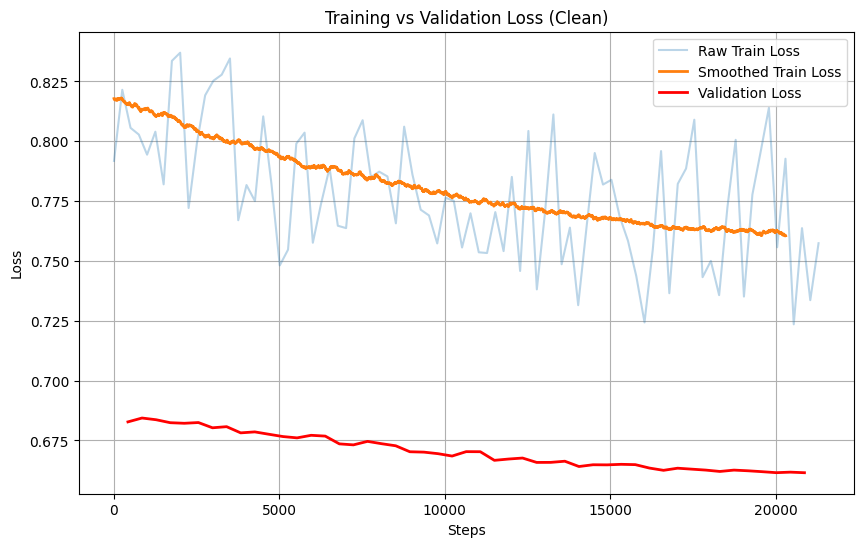

In [62]:
plt.figure(figsize=(10,6))

# Raw (light)
plt.plot(steps[::50], train_loss[::50], alpha=0.3, label="Raw Train Loss")

# Smoothed (main)
plt.plot(smooth_steps, smooth_train, linewidth=2, label="Smoothed Train Loss")

# Validation
plt.plot(eval_steps, eval_loss, linewidth=2, color="red", label="Validation Loss")

plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Clean)")
plt.legend()
plt.grid(True)

plt.show()

In [10]:
model.save_pretrained("/home/icmr-proj/final_ligand_model_50_epoch_2")

In [21]:
import pandas as pd

# Load JSONL
df = pd.read_json("train_pocket_only.jsonl", lines=True)

print("Columns:", df.columns)
print("Null counts:\n", df.isnull().sum())

Columns: Index(['instruction', 'input', 'output'], dtype='object')
Null counts:
 instruction    0
input          0
output         0
dtype: int64


In [22]:
# Remove null / empty SMILES
df = df[
    df["output"].notnull() &
    (df["output"].astype(str).str.strip() != "")
].reset_index(drop=True)

print("After cleaning:", len(df))

After cleaning: 7571


In [23]:
from rdkit import Chem

def is_valid_smiles(smiles):
    try:
        return Chem.MolFromSmiles(smiles) is not None
    except:
        return False

df["is_valid"] = df["output"].apply(is_valid_smiles)

print("Valid SMILES:", df["is_valid"].sum())
print("Invalid SMILES:", (~df["is_valid"]).sum())
print("Validity %:", df["is_valid"].mean() * 100)

[18:46:17] WARNING: not removing hydrogen atom with neighbor that has non-tetrahedral stereochemistry
[18:46:17] WARNING: not removing hydrogen atom with neighbor that has non-tetrahedral stereochemistry
[18:46:17] WARNING: not removing hydrogen atom with neighbor that has non-tetrahedral stereochemistry
[18:46:17] WARNING: not removing hydrogen atom with neighbor that has non-tetrahedral stereochemistry
[18:46:18] WARNING: not removing hydrogen atom with neighbor that has non-tetrahedral stereochemistry
[18:46:18] WARNING: not removing hydrogen atom with neighbor that has non-tetrahedral stereochemistry
[18:46:18] WARNING: not removing hydrogen atom with neighbor that has non-tetrahedral stereochemistry
[18:46:18] WARNING: not removing hydrogen atom with neighbor that has non-tetrahedral stereochemistry
[18:46:18] WARNING: not removing hydrogen atom with neighbor that has non-tetrahedral stereochemistry


Valid SMILES: 7571
Invalid SMILES: 0
Validity %: 100.0


[18:46:19] WARNING: not removing hydrogen atom with neighbor that has non-tetrahedral stereochemistry
[18:46:19] WARNING: not removing hydrogen atom with neighbor that has non-tetrahedral stereochemistry
[18:46:19] WARNING: not removing hydrogen atom with neighbor that has non-tetrahedral stereochemistry
[18:46:19] WARNING: not removing hydrogen atom with neighbor that has non-tetrahedral stereochemistry
[18:46:19] WARNING: not removing hydrogen atom with neighbor that has non-tetrahedral stereochemistry


In [24]:
df = df[df["is_valid"]].drop_duplicates(subset=["output"]).reset_index(drop=True)

In [26]:
dataset = df.to_dict(orient="records")
dataset

[{'instruction': 'Generate a valid, drug-like SMILES that binds to the given protein pocket.',
  'input': "Pocket residues: PHE, MET, CYS, GLY, GLU, ARG, LEU, ILE, ASP, LYS, VAL, THR, ALA, SER, ASN, GLN, TRP, TYR, PRO, HIS;\nResidue frequency: {'HIS': 5, 'THR': 6, 'TYR': 6, 'ASP': 7, 'PRO': 5, 'ALA': 4, 'PHE': 7, 'ARG': 4, 'LEU': 15, 'SER': 14, 'MET': 5, 'VAL': 7, 'ILE': 6, 'GLN': 4, 'LYS': 8, 'GLU': 6, 'ASN': 4, 'TRP': 1, 'CYS': 1, 'GLY': 3};\nPocket center: [6.32, 3.59, 57.58];\nPocket size: 1939 atoms;\nHydrophobic ratio: 0;\nPolar ratio: 0;\nH-bond donors: 43;\nH-bond acceptors: 26;\nAromatic residues: 19; Binding affinity (pKd): 8.75",
  'output': 'C=C1[C@H](O)CC(=CC=C2CCC[C@]3(C)[C@@H]([C@H](C)[C@H](CCCC)CC(O)(CC)CC)CC[C@@H]23)C[C@H]1O',
  'is_valid': True},
 {'instruction': 'Generate a valid, drug-like SMILES that binds to the given protein pocket.',
  'input': "Pocket residues: PHE, MET, CYS, GLY, GLU, ARG, LEU, ILE, ASP, LYS, VAL, THR, ALA, SER, ASN, GLN, TRP, TYR, PRO, HIS;\n

In [13]:
# Check if LoRA is actually training anything
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable Parameters: {trainable_params}") # Should NOT be 0




Trainable Parameters: 1769472


In [ ]:
###########################################

In [5]:
import torch
from rdkit import Chem
from rdkit.Chem import QED, RDConfig
import os
import sys
from tqdm import tqdm

import torch
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
from peft import PeftModel, PeftConfig

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model_path = "/home/icmr-proj/final_ligand_model_50_epoch_2"

config = PeftConfig.from_pretrained(model_path)

tokenizer = AutoTokenizer.from_pretrained(config.base_model_name_or_path)

base_model = AutoModelForSeq2SeqLM.from_pretrained(config.base_model_name_or_path)

model = PeftModel.from_pretrained(base_model, model_path)

model = model.to(DEVICE)
model.eval()

def fix_duplicate_ring_closures(smiles):
    # This identifies if a number like '3' is being used incorrectly
    # and tries to simplify it.
    for i in range(1, 10):
        # Find if a digit appears too close to itself or twice in a way that suggests a duplicate bond
        if smiles.count(str(i)) > 2:
            # Simple fix: keep only the first two occurrences of each ring digit
            parts = smiles.split(str(i))
            smiles = str(i).join(parts[:3]) + "".join(parts[3:])
    return smiles
def clean_smiles_string(smiles):
    # Remove any stray spaces or weird characters the model hallucinated
    smiles = smiles.strip().split()[0] if smiles.strip() else ""

    # Try to fix the most common neural error: unclosed parentheses
    open_p = smiles.count('(')
    close_p = smiles.count(')')
    if open_p > close_p:
        smiles += ')' * (open_p - close_p)

    return smiles
# 2. Evaluation Logic
def evaluate_model(dataset_test, num_samples=50):
    valid_count = 0
    qed_scores = []

    print(f"Evaluating {num_samples} samples...")
    for i in tqdm(range(num_samples)):
        input_text = dataset_test[i]["input"]
        ground_truth = dataset_test[i]["output"]

        # Generate
        inputs = tokenizer(input_text, return_tensors="pt", truncation=True, max_length=512).to("cuda")
        with torch.no_grad():
            outputs = model.generate(**inputs,max_length=128,num_beams=5,repetition_penalty=1.2, temperature=0.7,do_sample=True,early_stopping=True)

        gen_smiles = tokenizer.decode(outputs[0], skip_special_tokens=True).replace(" ", "")

        if not gen_smiles:
          print("Warning: Model generated an empty string!")
        else:
          print(f"Testing SMILES: {gen_smiles}")

        # Check Validity with RDKit
        mol = Chem.MolFromSmiles(gen_smiles)
        if mol:
            valid_count += 1
            qed_scores.append(QED.qed(mol))

    validity_rate = (valid_count / num_samples) * 100
    avg_qed = sum(qed_scores) / len(qed_scores) if qed_scores else 0

    print(f"\n--- Performance Results ---")
    print(f"Validity Rate: {validity_rate:.2f}%")
    print(f"Average QED (Drug-likeness): {avg_qed:.4f}")
    return validity_rate, avg_qed

# Run evaluation on your test split
evaluate_model(dataset)


Evaluating 50 samples...


  0%|                                                    | 0/50 [00:00<?, ?it/s]


KeyError: "Invalid key: 0. Please first select a split. For example: `my_dataset_dictionary['train'][0]`. Available splits: ['test', 'train']"

In [13]:
import json
from tqdm import tqdm
from rdkit import Chem
from rdkit.Chem import QED

# -------------------------------
# CONFIG
# -------------------------------
TEST_FILE = "clean_training_data.jsonl"

# -------------------------------
# LOAD JSONL
# -------------------------------
def stream_jsonl(path):
    with open(path, "r") as f:
        for line in f:
            if line.strip():
                yield json.loads(line)

# -------------------------------
# EVALUATION
# -------------------------------
def evaluate_ground_truth():
    total = 0
    valid_count = 0
    qed_scores = []
    invalid_smiles = []

    print("🔍 Checking ground-truth SMILES...\n")

    for sample in tqdm(stream_jsonl(TEST_FILE)):
        smiles = sample.get("output", "").strip()

        if not smiles:
            continue

        total += 1

        mol = Chem.MolFromSmiles(smiles)

        if mol:
            valid_count += 1
            qed_val = QED.qed(mol)
            qed_scores.append(qed_val)
        else:
            invalid_smiles.append(smiles[:50])

    # -------------------------------
    # METRICS
    # -------------------------------
    validity = (valid_count / total) * 100 if total else 0
    avg_qed = sum(qed_scores) / len(qed_scores) if qed_scores else 0

    print("\n" + "="*50)
    print("📊 GROUND TRUTH DATASET QUALITY")
    print("="*50)
    print(f"Total SMILES    : {total}")
    print(f"Valid SMILES    : {valid_count}")
    print(f"Validity Rate   : {validity:.2f}%")
    print(f"Average QED     : {avg_qed:.4f}")
    print(f"Invalid Count   : {len(invalid_smiles)}")
    print("="*50)

    # Optional: print some invalid examples
    if invalid_smiles:
        print("\n❌ Sample Invalid SMILES:")
        for sm in invalid_smiles[:5]:
            print("-", sm)

# -------------------------------
# RUN
# -------------------------------
if __name__ == "__main__":
    evaluate_ground_truth()

🔍 Checking ground-truth SMILES...



132it [00:00, 422.46it/s][11:09:21] Explicit valence for atom # 22 P, 6, is greater than permitted
280it [00:00, 478.07it/s][11:09:21] Explicit valence for atom # 16 P, 6, is greater than permitted
520it [00:01, 570.16it/s][11:09:21] Explicit valence for atom # 3 P, 6, is greater than permitted
801it [00:01, 543.78it/s][11:09:22] Explicit valence for atom # 7 P, 6, is greater than permitted
1674it [00:03, 569.17it/s][11:09:24] Explicit valence for atom # 9 P, 6, is greater than permitted
2345it [00:04, 565.35it/s][11:09:25] Explicit valence for atom # 18 P, 6, is greater than permitted
2476it [00:04, 606.60it/s][11:09:25] Explicit valence for atom # 18 P, 6, is greater than permitted
2917it [00:05, 572.44it/s][11:09:26] Explicit valence for atom # 2 P, 6, is greater than permitted
3037it [00:05, 581.38it/s][11:09:26] Explicit valence for atom # 10 P, 6, is greater than permitted
3660it [00:06, 609.79it/s][11:09:27] Explicit valence for atom # 28 P, 6, is greater than permitted
4168it [


📊 GROUND TRUTH DATASET QUALITY
Total SMILES    : 58175
Valid SMILES    : 57953
Validity Rate   : 99.62%
Average QED     : 0.7524
Invalid Count   : 222

❌ Sample Invalid SMILES:
- Nc1ncnc2c1ncn2CCOC[P@@](=O)([O-])O[P@@](=O)([O-])O
- CC(=O)N[C@@H](Cc1ccc(OCC(=O)[O-])c([P+](=O)(=O)[O-
- O=C([O-])[P+](=O)(=O)[O-]
- O=C([O-])C1=C[C@@H](O[P+](=O)(=O)[O-])[C@@H](O)[C@
- NC(=O)c1ccc(OC[P+](=O)(=O)[O-])c2c1Cc1scnc1-2


In [7]:
# =========================
# 1. SETUP
# =========================
import torch
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
from peft import PeftModel, PeftConfig

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

MODEL_PATH = "/home/icmr-proj/final_ligand_model_50_epoch_2"

# Load config (ensures correct base model)
config = PeftConfig.from_pretrained(MODEL_PATH)

BASE_MODEL = config.base_model_name_or_path
print("Base model:", BASE_MODEL)

# Load tokenizer (IMPORTANT - you missed this earlier)
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

# Load base model
base_model = AutoModelForSeq2SeqLM.from_pretrained(BASE_MODEL)

# Load LoRA adapter
model = PeftModel.from_pretrained(base_model, MODEL_PATH)

model = model.to(DEVICE)
model.eval()

# =========================
# 2. CLEANING FUNCTION
# =========================
def clean_smiles(smiles):
    if not smiles:
        return ""

    smiles = smiles.strip().replace(" ", "")

    # Fix parentheses imbalance (common LLM error)
    if smiles.count("(") > smiles.count(")"):
        smiles += ")" * (smiles.count("(") - smiles.count(")"))

    return smiles


# =========================
# 3. GENERATION FUNCTION
# =========================
def generate_ligand_from_pocket(pocket_input):
    """
    Generate SMILES from protein pocket description
    """

    # Tokenize input
    inputs = tokenizer(
        pocket_input,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    # ✅ Move inputs to same device as model
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    # Generate
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=128,
            num_beams=5,              # balanced (10 is too heavy)
            repetition_penalty=2.0,   # avoid repetition
            temperature=0.7,
            do_sample=True,
            top_p=0.9,
            early_stopping=True
        )

    # Decode
    gen_smiles = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Clean output
    gen_smiles = clean_smiles(gen_smiles)

    return gen_smiles


# =========================
# 4. TEST INPUT
# =========================
test_pocket = """Pocket residues: PHE, MET, CYS, GLY, GLU, ARG, LEU, ILE, ASP, LYS, VAL, THR, ALA, SER, ASN, GLN, TRP, TYR, PRO, HIS;
Residue frequency: {'ILE': 6, 'PHE': 3, 'TYR': 6, 'VAL': 5, 'CYS': 6, 'GLY': 10, 'SER': 6, 'ALA': 6, 'THR': 7, 'HIS': 3, 'ASP': 8, 'LEU': 4, 'LYS': 5, 'ASN': 1, 'GLU': 1, 'MET': 1, 'TRP': 2, 'GLN': 1, 'PRO': 2, 'ARG': 1};
Pocket center: [30.49, 4.21, 29.47];
Pocket size: 1260 atoms;
Hydrophobic ratio: 0;
Polar ratio: 0;
H-bond donors: 28;
H-bond acceptors: 14;
Aromatic residues: 14;
Binding affinity (pKd): 7.55
"""

# =========================
# 5. GENERATE
# =========================
result_smiles = generate_ligand_from_pocket(test_pocket)

print("Generated SMILES:", result_smiles)

Using device: cuda
Base model: laituan245/molt5-base-smiles2caption


/home/cup/anaconda3/envs/lora_env/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Generated SMILES: CC(C)[C@H](NC(=O)[C@@H](Cc1ccccc1)N[C]([O-])OCc1ccccc1)C(=O)N[C@@H](CCCNC(N)=[NH2+])C(=O)[O-]


In [7]:
import pandas as pd

df = pd.read_json("final_training_data.jsonl", lines=True)

print("Total samples:", len(df))
print(df.columns)

Total samples: 111
Index(['instruction', 'input', 'output'], dtype='object')


In [37]:
dataset = df.to_dict(orient="records")
len(dataset)

111

In [9]:
from rdkit import Chem
from rdkit.Chem import QED
from tqdm import tqdm

In [10]:
def evaluate_on_jsonl(dataset, num_samples=None):

    valid_count = 0
    total = 0
    qed_scores = []

    results = []

    if num_samples:
        dataset = dataset[:num_samples]

    print(f"\nEvaluating {len(dataset)} samples...\n")

    for sample in tqdm(dataset):

        input_text = sample["input"]
        true_smiles = sample["output"]

        # Generate
        gen_smiles = generate_ligand_from_pocket(input_text)

        # Validate
        mol = Chem.MolFromSmiles(gen_smiles)

        is_valid = mol is not None

        if is_valid:
            valid_count += 1
            qed_scores.append(QED.qed(mol))

        total += 1

        # Store results
        results.append({
            "input": input_text,
            "true_smiles": true_smiles,
            "generated_smiles": gen_smiles,
            "valid": is_valid
        })

        # Optional debug print
        print(f"\nGenerated: {gen_smiles}")
        print(f"Valid: {is_valid}")

    # Final metrics
    validity_rate = (valid_count / total) * 100
    avg_qed = sum(qed_scores) / len(qed_scores) if qed_scores else 0

    print("\n======================")
    print("FINAL RESULTS")
    print("======================")
    print(f"Total Samples: {total}")
    print(f"Valid Molecules: {valid_count}")
    print(f"Validity Rate: {validity_rate:.2f}%")
    print(f"Average QED: {avg_qed:.4f}")

    return results, validity_rate, avg_qed

In [11]:
results, validity, qed = evaluate_on_jsonl(dataset, num_samples=50)


Evaluating 50 samples...



  2%|▉                                           | 1/50 [00:04<04:00,  4.91s/it]


Generated: O=C([O-])c1ccc2c(c1)CCCN2C(=O)[C@@H](Cc1ccccc1)NC(=O)[C@@H]([NH3+])Cc1ccccc1
Valid: True


  4%|█▊                                          | 2/50 [00:06<02:33,  3.20s/it]


Generated: O=C([O-])c1ccc(S(=O)(=O)N2CCOCC2)cc1
Valid: True


...


Generated: O=C([O-])c1ccc(NC(=O)Nc2ccc(S(=O)(=O)N3CCOCC3)cc2)cc1
Valid: True


 98%|██████████████████████████████████████████▏| 49/50 [01:45<00:01,  1.70s/it]


Generated: O=C([O-])c1ccc(-c2ccc3c(c2)OCO3)cc1
Valid: True


100%|███████████████████████████████████████████| 50/50 [01:47<00:00,  2.16s/it]


Generated: O=C([O-])c1ccc(S(=O)(=O)N2CC[NH+](Cc3ccccc3)CC2)cc1
Valid: True

FINAL RESULTS
Total Samples: 50
Valid Molecules: 50
Validity Rate: 100.00%
Average QED: 0.6835


In [ ]:
C=CCN(C(=O)c1cc(Cl)cc(OCCCONC(N)=[NH2+])c1)C1CCCC1

In [39]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df.to_csv("generation_results_50_epochs.csv", index=False)

In [12]:

import pandas as pd

results_df = pd.DataFrame(results)

results_df.to_csv("generation_results_50_epochs_testing.csv", index=False)


In [40]:
train_smiles = set(df["output"])
train_smiles = set(df["output"])

generated_smiles = [r["generated_smiles"] for r in results]

novel = [s for s in generated_smiles if s not in train_smiles]

print("Novel molecules:", len(novel))
print("Novelty %:", len(novel) / len(generated_smiles) * 100)
generated_smiles = [r["generated_smiles"] for r in results]

novel = [s for s in generated_smiles if s not in train_smiles]

print("Novel molecules:", len(novel))
print("Novelty %:", len(novel) / len(generated_smiles) * 100)

Novel molecules: 50
Novelty %: 100.0
Novel molecules: 50
Novelty %: 100.0


In [13]:
train_smiles = set(df["output"])
train_smiles = set(df["output"])

generated_smiles = [r["generated_smiles"] for r in results]

novel = [s for s in generated_smiles if s not in train_smiles]

print("Novel molecules:", len(novel))
print("Novelty %:", len(novel) / len(generated_smiles) * 100)
generated_smiles = [r["generated_smiles"] for r in results]

novel = [s for s in generated_smiles if s not in train_smiles]

print("Novel molecules:", len(novel))
print("Novelty %:", len(novel) / len(generated_smiles) * 100)

Novel molecules: 50
Novelty %: 100.0
Novel molecules: 50
Novelty %: 100.0


In [41]:
unique_smiles = set(generated_smiles)

print("Unique molecules:", len(unique_smiles))
print("Uniqueness %:", len(unique_smiles) / len(generated_smiles) * 100)

Unique molecules: 12
Uniqueness %: 24.0


In [14]:
unique_smiles = set(generated_smiles)

print("Unique molecules:", len(unique_smiles))
print("Uniqueness %:", len(unique_smiles) / len(generated_smiles) * 100)

Unique molecules: 15
Uniqueness %: 30.0


In [42]:
from rdkit import DataStructs
from rdkit.Chem import AllChem

def tanimoto_similarity(s1, s2):
    m1 = Chem.MolFromSmiles(s1)
    m2 = Chem.MolFromSmiles(s2)
    if m1 and m2:
        fp1 = AllChem.GetMorganFingerprintAsBitVect(m1, 2)
        fp2 = AllChem.GetMorganFingerprintAsBitVect(m2, 2)
        return DataStructs.TanimotoSimilarity(fp1, fp2)
    return 0

# average similarity (lower = better diversity)
sims = []
for i in range(len(generated_smiles)):
    for j in range(i+1, len(generated_smiles)):
        sims.append(tanimoto_similarity(generated_smiles[i], generated_smiles[j]))

print("Avg similarity:", sum(sims)/len(sims))

[19:04:18] DEPRECATION WARNING: please use MorganGenerator
[19:04:18] DEPRECATION WARNING: please use MorganGenerator
[19:04:18] DEPRECATION WARNING: please use MorganGenerator
[19:04:18] DEPRECATION WARNING: please use MorganGenerator
[19:04:18] DEPRECATION WARNING: please use MorganGenerator
[19:04:18] DEPRECATION WARNING: please use MorganGenerator
[19:04:18] DEPRECATION WARNING: please use MorganGenerator
[19:04:18] DEPRECATION WARNING: please use MorganGenerator
[19:04:18] DEPRECATION WARNING: please use MorganGenerator
[19:04:18] DEPRECATION WARNING: please use MorganGenerator
[19:04:18] DEPRECATION WARNING: please use MorganGenerator
[19:04:18] DEPRECATION WARNING: please use MorganGenerator
[19:04:18] DEPRECATION WARNING: please use MorganGenerator
[19:04:18] DEPRECATION WARNING: please use MorganGenerator
[19:04:18] DEPRECATION WARNING: please use MorganGenerator
[19:04:18] DEPRECATION WARNING: please use MorganGenerator
[19:04:18] DEPRECATION WARNING: please use MorganGenerat

[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerat

[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerat

[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerat

[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerat

Avg similarity: 0.4657804425191605


[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerator
[19:04:19] DEPRECATION WARNING: please use MorganGenerat

In [43]:
from rdkit.Chem import Descriptors

def lipinski(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return False
    return (
        Descriptors.MolWt(mol) < 500 and
        Descriptors.NumHDonors(mol) <= 5 and
        Descriptors.NumHAcceptors(mol) <= 10 and
        Descriptors.MolLogP(mol) < 5
    )

lipinski_pass = sum(lipinski(s) for s in generated_smiles)

print("Lipinski pass %:", lipinski_pass / len(generated_smiles) * 100)

Lipinski pass %: 70.0


In [15]:
from rdkit.Chem import Descriptors

def lipinski(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return False
    return (
        Descriptors.MolWt(mol) < 500 and
        Descriptors.NumHDonors(mol) <= 5 and
        Descriptors.NumHAcceptors(mol) <= 10 and
        Descriptors.MolLogP(mol) < 5
    )

lipinski_pass = sum(lipinski(s) for s in generated_smiles)

print("Lipinski pass %:", lipinski_pass / len(generated_smiles) * 100)

Lipinski pass %: 96.0


In [16]:
# =========================
# 1. SETUP
# =========================
import torch
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
from peft import PeftModel, PeftConfig

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

MODEL_PATH = "/home/icmr-proj/final_ligand_model_50_epoch_2"

# Load config (ensures correct base model)
config = PeftConfig.from_pretrained(MODEL_PATH)

BASE_MODEL = config.base_model_name_or_path
print("Base model:", BASE_MODEL)

# Load tokenizer (IMPORTANT - you missed this earlier)
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

# Load base model
base_model = AutoModelForSeq2SeqLM.from_pretrained(BASE_MODEL)

# Load LoRA adapter
model = PeftModel.from_pretrained(base_model, MODEL_PATH)

model = model.to(DEVICE)
model.eval()

# =========================
# 2. CLEANING FUNCTION
# =========================
def clean_smiles(smiles):
    if not smiles:
        return ""

    smiles = smiles.strip().replace(" ", "")

    # Fix parentheses imbalance (common LLM error)
    if smiles.count("(") > smiles.count(")"):
        smiles += ")" * (smiles.count("(") - smiles.count(")"))

    return smiles


from rdkit import Chem

def generate_ligand_from_pocket(pocket_input, generated_smiles=None):
    """
    Generate SMILES from protein pocket description
    with diversity + validity filtering
    """

    if generated_smiles is None:
        generated_smiles = []

    # Tokenize input
    inputs = tokenizer(
        pocket_input,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    # Move to device
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    # Generate multiple candidates
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=128,

            do_sample=True,            # 🔥 MUST
            top_p=0.95,
            top_k=50,
            temperature=1.1,
            repetition_penalty=1.2,

            num_return_sequences=5     # 🔥 multiple candidates
        )

    # Decode all candidates
    candidates = [
        clean_smiles(
            tokenizer.decode(o, skip_special_tokens=True)
        )
        for o in outputs
    ]

    # ✅ Select best: valid + unique
    for smi in candidates:
        if smi and smi not in generated_smiles:
            mol = Chem.MolFromSmiles(smi)
            if mol:
                return smi

    # Fallback (if all fail)
    return candidates[0] if candidates else ""


# =========================
# 4. TEST INPUT
# =========================
test_pocket = """Pocket residues: PHE, MET, CYS, GLY, GLU, ARG, LEU, ILE, ASP, LYS, VAL, THR, ALA, SER, ASN, GLN, TRP, TYR, PRO, HIS;
Residue frequency: {'ILE': 6, 'PHE': 3, 'TYR': 6, 'VAL': 5, 'CYS': 6, 'GLY': 10, 'SER': 6, 'ALA': 6, 'THR': 7, 'HIS': 3, 'ASP': 8, 'LEU': 4, 'LYS': 5, 'ASN': 1, 'GLU': 1, 'MET': 1, 'TRP': 2, 'GLN': 1, 'PRO': 2, 'ARG': 1};
Pocket center: [30.49, 4.21, 29.47];
Pocket size: 1260 atoms;
Hydrophobic ratio: 0;
Polar ratio: 0;
H-bond donors: 28;
H-bond acceptors: 14;
Aromatic residues: 14;
Binding affinity (pKd): 7.55
"""

# =========================
# 5. GENERATE
# =========================
result_smiles = generate_ligand_from_pocket(test_pocket)

print("Generated SMILES:", result_smiles)

Using device: cuda
Base model: laituan245/molt5-base-smiles2caption


/home/cup/anaconda3/envs/lora_env/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Generated SMILES: O=C(c1nc2cc(-c3cnc(NC4CCCC4)s3)ncc2[nH]1)c1cn(Cc2ccccc2)cn1


In [17]:
def evaluate_on_jsonl(dataset, num_samples=None):

    valid_count = 0
    total = 0
    qed_scores = []

    results = []

    if num_samples:
        dataset = dataset[:num_samples]

    print(f"\nEvaluating {len(dataset)} samples...\n")

    for sample in tqdm(dataset):

        input_text = sample["input"]
        true_smiles = sample["output"]

        # Generate
        gen_smiles = generate_ligand_from_pocket(input_text)

        # Validate
        mol = Chem.MolFromSmiles(gen_smiles)

        is_valid = mol is not None

        if is_valid:
            valid_count += 1
            qed_scores.append(QED.qed(mol))

        total += 1

        # Store results
        results.append({
            "input": input_text,
            "true_smiles": true_smiles,
            "generated_smiles": gen_smiles,
            "valid": is_valid
        })

        # Optional debug print
        print(f"\nGenerated: {gen_smiles}")
        print(f"Valid: {is_valid}")

    # Final metrics
    validity_rate = (valid_count / total) * 100
    avg_qed = sum(qed_scores) / len(qed_scores) if qed_scores else 0

    print("\n======================")
    print("FINAL RESULTS")
    print("======================")
    print(f"Total Samples: {total}")
    print(f"Valid Molecules: {valid_count}")
    print(f"Validity Rate: {validity_rate:.2f}%")
    print(f"Average QED: {avg_qed:.4f}")

    return results, validity_rate, avg_qed

In [28]:
results, validity, qed = evaluate_on_jsonl(dataset, num_samples= 111)


Evaluating 111 samples...



  0%|                                                   | 0/111 [00:00<?, ?it/s][10:35:23] non-ring atom 5 marked aromatic
[10:35:23] SMILES Parse Error: ring closure 1 duplicates bond between atom 33 and atom 34 for input: 'Cc1nc2c(C)cc(O[S@+](=O)([O-])N(CCS(=O)(=O)CCCCNC1=O)c3ccccc3)cc2n1-c1ccc(F)c(F)c1'
[10:35:23] SMILES Parse Error: ring closure 2 duplicates bond between atom 22 and atom 23 for input: 'CC[C@H](NS(=O)(=O)c1c(-c2cccn2c(N3CCCC3)nnc2-n2)C(F)(F)F)C(=O)N1C'
  1%|▍                                          | 1/111 [00:02<05:15,  2.87s/it]


Generated: C(=O)N[C@@H]1CCc2ccccc21
Valid: True


[10:35:26] SMILES Parse Error: unclosed ring for input: 'CC(C)c1c[nH]c2c(NCc3ccsc3)nc(-c3ccc4nccc(-c5cn[nH]c5)c4)nc23'
[10:35:26] SMILES Parse Error: unclosed ring for input: 'NS(=O)(=O)c1cc(-c2nc3c4cc5[nH]ccc5cc4n2C2)n(CC[NH2+]2CCOCC2)n1'
  2%|▊                                          | 2/111 [00:05<05:05,  2.80s/it]


Generated: NS(=O)(=O)c1ccc(CCNC2CCCCC2)c(-c2c[nH]nc2-c2c(Cl)c(F)cc(F)c2Cl)c1
Valid: True


...


Generated: [NH3+][C@H](CC(=O)[O-])C(=O)NO
Valid: True


 99%|████████████████████████████████████████▋| 110/111 [03:59<00:02,  2.40s/it]


Generated: Cc1nc(-c2cccnc2)sc1[C@H](O)CC[NH2+][C@@H]1OCO[C@H](CO[P@@](=O)([O-])OCCO)[C@H]1O
Valid: True


100%|█████████████████████████████████████████| 111/111 [04:02<00:00,  2.18s/it]


Generated: COc1c(C)cc(-c2ccnc(N3CC[NH+](C)CC3)c2)cc1O
Valid: True

FINAL RESULTS
Total Samples: 111
Valid Molecules: 109
Validity Rate: 98.20%
Average QED: 0.5850


In [ ]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df.to_csv("generation_results_50_epochs_unique.csv", index=False)

In [29]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df.to_csv("generation_results_50_epochs_unique_testing.csv", index=False)


In [68]:
train_smiles = set(df["output"])
train_smiles = set(df["output"])

generated_smiles = [r["generated_smiles"] for r in results]

novel = [s for s in generated_smiles if s not in train_smiles]

print("Novel molecules:", len(novel))
print("Novelty %:", len(novel) / len(generated_smiles) * 100)
generated_smiles = [r["generated_smiles"] for r in results]

novel = [s for s in generated_smiles if s not in train_smiles]

print("Novel molecules:", len(novel))
print("Novelty %:", len(novel) / len(generated_smiles) * 100)

Novel molecules: 50
Novelty %: 100.0
Novel molecules: 50
Novelty %: 100.0


In [30]:
train_smiles = set(df["output"])
train_smiles = set(df["output"])

generated_smiles = [r["generated_smiles"] for r in results]

novel = [s for s in generated_smiles if s not in train_smiles]

print("Novel molecules:", len(novel))
print("Novelty %:", len(novel) / len(generated_smiles) * 100)
generated_smiles = [r["generated_smiles"] for r in results]

novel = [s for s in generated_smiles if s not in train_smiles]

print("Novel molecules:", len(novel))
print("Novelty %:", len(novel) / len(generated_smiles) * 100)

Novel molecules: 111
Novelty %: 100.0
Novel molecules: 111
Novelty %: 100.0


In [69]:
unique_smiles = set(generated_smiles)

print("Unique molecules:", len(unique_smiles))
print("Uniqueness %:", len(unique_smiles) / len(generated_smiles) * 100)

Unique molecules: 50
Uniqueness %: 100.0


In [31]:
unique_smiles = set(generated_smiles)

print("Unique molecules:", len(unique_smiles))
print("Uniqueness %:", len(unique_smiles) / len(generated_smiles) * 100)

Unique molecules: 111
Uniqueness %: 100.0


In [73]:
from rdkit import Chem
from rdkit import DataStructs
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

morgan_gen = GetMorganGenerator(radius=2)

def tanimoto_similarity(s1, s2):
    m1 = Chem.MolFromSmiles(s1)
    m2 = Chem.MolFromSmiles(s2)

    if m1 and m2:
        fp1 = morgan_gen.GetFingerprint(m1)
        fp2 = morgan_gen.GetFingerprint(m2)
        return DataStructs.TanimotoSimilarity(fp1, fp2)

    return 0



sims = []
for i in range(len(generated_smiles)):
    for j in range(i+1, len(generated_smiles)):
        sims.append(tanimoto_similarity(generated_smiles[i], generated_smiles[j]))

print("Average similarity:", sum(sims)/len(sims))

Average similarity: 0.10550364205671761


In [32]:
from rdkit import Chem
from rdkit import DataStructs
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

morgan_gen = GetMorganGenerator(radius=2)

def tanimoto_similarity(s1, s2):
    m1 = Chem.MolFromSmiles(s1)
    m2 = Chem.MolFromSmiles(s2)

    if m1 and m2:
        fp1 = morgan_gen.GetFingerprint(m1)
        fp2 = morgan_gen.GetFingerprint(m2)
        return DataStructs.TanimotoSimilarity(fp1, fp2)

    return 0



sims = []
for i in range(len(generated_smiles)):
    for j in range(i+1, len(generated_smiles)):
        sims.append(tanimoto_similarity(generated_smiles[i], generated_smiles[j]))

print("Average similarity:", sum(sims)/len(sims))

[10:39:53] SMILES Parse Error: unclosed ring for input: 'CC[C@H](C)n1nc(-c2cn3c(n2)CCc2cc(=O)[nH]n2C)cc1C(N)=O'
[10:39:53] Can't kekulize mol.  Unkekulized atoms: 14 15 16 17 24
[10:39:53] SMILES Parse Error: unclosed ring for input: 'CC[C@H](C)n1nc(-c2cn3c(n2)CCc2cc(=O)[nH]n2C)cc1C(N)=O'
[10:39:53] Can't kekulize mol.  Unkekulized atoms: 14 15 16 17 24
[10:39:53] SMILES Parse Error: unclosed ring for input: 'CC[C@H](C)n1nc(-c2cn3c(n2)CCc2cc(=O)[nH]n2C)cc1C(N)=O'
[10:39:53] Can't kekulize mol.  Unkekulized atoms: 14 15 16 17 24
[10:39:53] SMILES Parse Error: unclosed ring for input: 'CC[C@H](C)n1nc(-c2cn3c(n2)CCc2cc(=O)[nH]n2C)cc1C(N)=O'
[10:39:53] Can't kekulize mol.  Unkekulized atoms: 14 15 16 17 24
[10:39:53] SMILES Parse Error: unclosed ring for input: 'CC[C@H](C)n1nc(-c2cn3c(n2)CCc2cc(=O)[nH]n2C)cc1C(N)=O'
[10:39:53] Can't kekulize mol.  Unkekulized atoms: 14 15 16 17 24
[10:39:53] SMILES Parse Error: unclosed ring for input: 'CC[C@H](C)n1nc(-c2cn3c(n2)CCc2cc(=O)[nH]n2C)cc1C(N)=O

Average similarity: 0.09516560783363709


In [71]:
from rdkit.Chem import Descriptors

def lipinski(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return False
    return (
        Descriptors.MolWt(mol) < 500 and
        Descriptors.NumHDonors(mol) <= 5 and
        Descriptors.NumHAcceptors(mol) <= 10 and
        Descriptors.MolLogP(mol) < 5
    )

lipinski_pass = sum(lipinski(s) for s in generated_smiles)

print("Lipinski pass %:", lipinski_pass / len(generated_smiles) * 100)

Lipinski pass %: 86.0


In [33]:
from rdkit.Chem import Descriptors

def lipinski(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return False
    return (
        Descriptors.MolWt(mol) < 500 and
        Descriptors.NumHDonors(mol) <= 5 and
        Descriptors.NumHAcceptors(mol) <= 10 and
        Descriptors.MolLogP(mol) < 5
    )

lipinski_pass = sum(lipinski(s) for s in generated_smiles)

print("Lipinski pass %:", lipinski_pass / len(generated_smiles) * 100)

Lipinski pass %: 84.68468468468468


[10:40:08] SMILES Parse Error: unclosed ring for input: 'CC[C@H](C)n1nc(-c2cn3c(n2)CCc2cc(=O)[nH]n2C)cc1C(N)=O'
[10:40:08] Can't kekulize mol.  Unkekulized atoms: 14 15 16 17 24


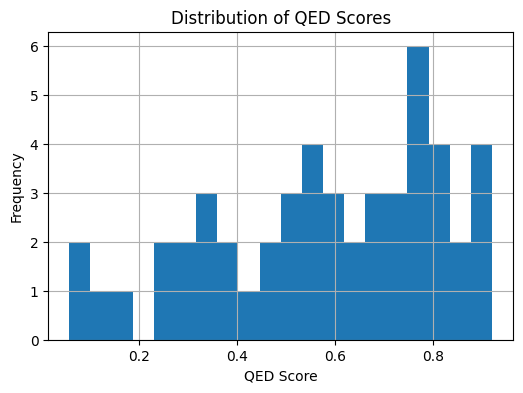

<Figure size 640x480 with 0 Axes>

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(qed_scores, bins=20)

plt.xlabel("QED Score")
plt.ylabel("Frequency")
plt.title("Distribution of QED Scores")
plt.grid(True)

plt.show()

plt.savefig("distribution_qed_50_epochs.png", dpi=300, bbox_inches='tight')

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(qed_scores, bins=20)

plt.xlabel("QED Score")
plt.ylabel("Frequency")
plt.title("Distribution of QED Scores")
plt.grid(True)

plt.show()

plt.savefig("distribution_qed_50_epochs_testing.png", dpi=300, bbox_inches='tight')

NameError: name 'qed_scores' is not defined

<Figure size 600x400 with 0 Axes>

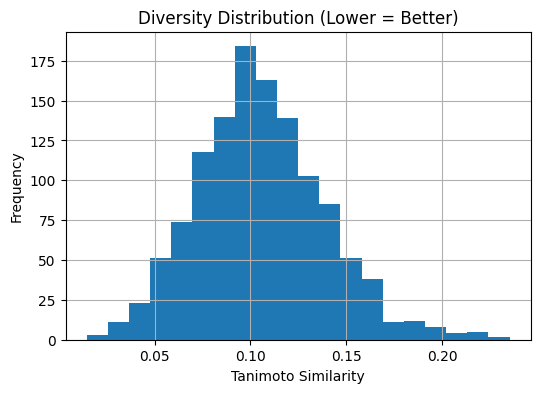

In [77]:
plt.figure(figsize=(6,4))
plt.hist(sims, bins=20)

plt.xlabel("Tanimoto Similarity")
plt.ylabel("Frequency")
plt.title("Diversity Distribution (Lower = Better)")
plt.grid(True)

plt.show()

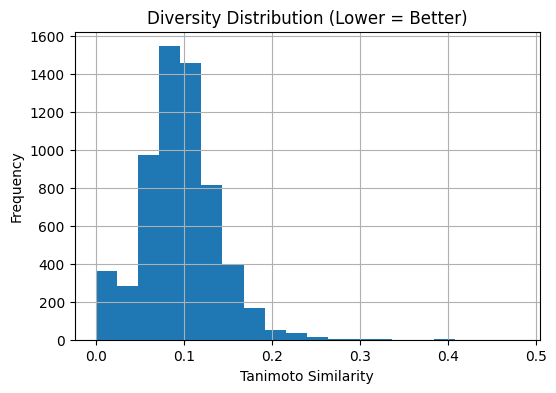

In [34]:
plt.figure(figsize=(6,4))
plt.hist(sims, bins=20)

plt.xlabel("Tanimoto Similarity")
plt.ylabel("Frequency")
plt.title("Diversity Distribution (Lower = Better)")
plt.grid(True)

plt.show()

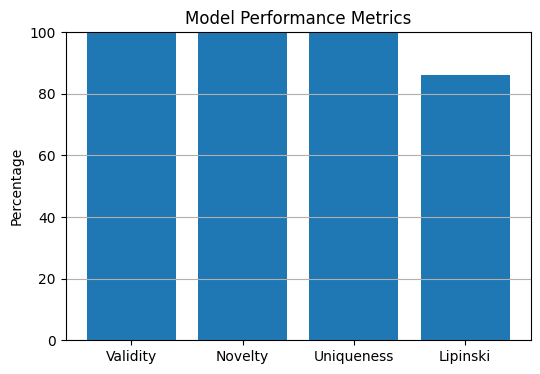

In [79]:
metrics = {
    "Validity": validity,
    "Novelty": 100,  # you already computed
    "Uniqueness": 100,
    "Lipinski": lipinski_pass / len(generated_smiles) * 100
}

plt.figure(figsize=(6,4))
plt.bar(metrics.keys(), metrics.values())

plt.ylabel("Percentage")
plt.title("Model Performance Metrics")

plt.ylim(0, 100)
plt.grid(axis='y')

plt.show()

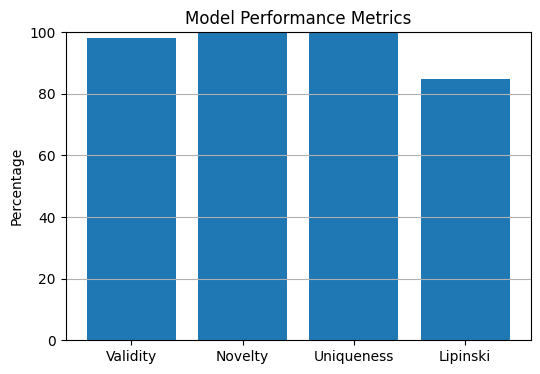

In [35]:
metrics = {
    "Validity": validity,
    "Novelty": 100,  # you already computed
    "Uniqueness": 100,
    "Lipinski": lipinski_pass / len(generated_smiles) * 100
}

plt.figure(figsize=(6,4))
plt.bar(metrics.keys(), metrics.values())

plt.ylabel("Percentage")
plt.title("Model Performance Metrics")

plt.ylim(0, 100)
plt.grid(axis='y')

plt.show()

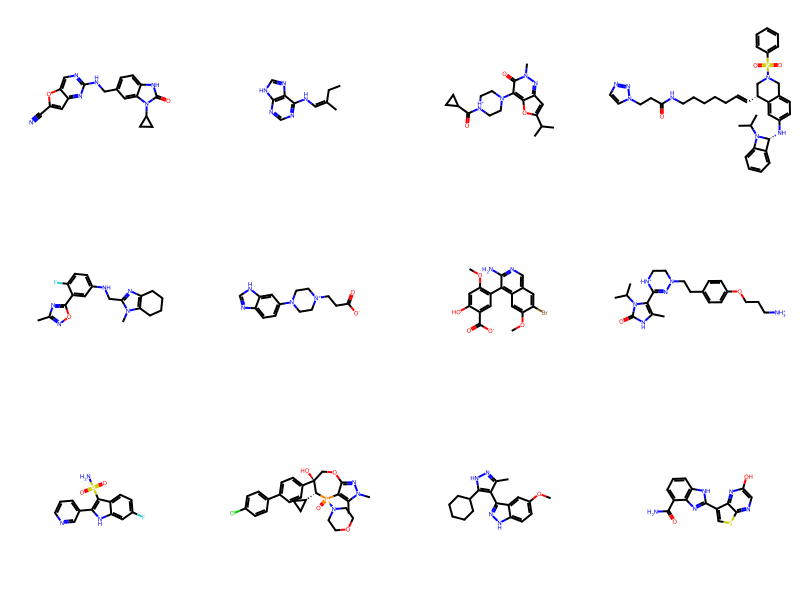

In [80]:
from rdkit.Chem import Draw

mols = [Chem.MolFromSmiles(s) for s in generated_smiles[:12]]

img = Draw.MolsToGridImage(
    mols,
    molsPerRow=4,
    subImgSize=(200,200)
)

display(img)

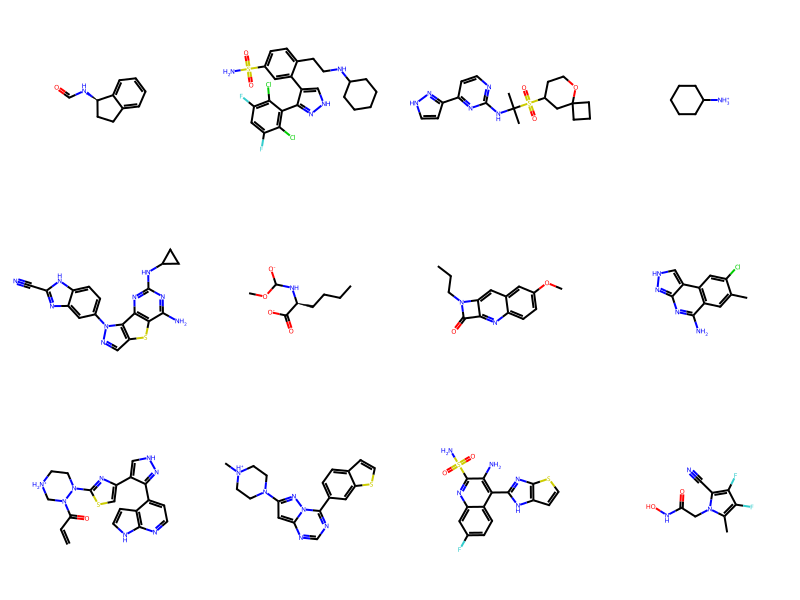

In [36]:
from rdkit.Chem import Draw

mols = [Chem.MolFromSmiles(s) for s in generated_smiles[:12]]

img = Draw.MolsToGridImage(
    mols,
    molsPerRow=4,
    subImgSize=(200,200)
)

display(img)

In [83]:
from rdkit import Chem
from rdkit.Chem import QED

qed_scores = []

for smi in generated_smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        qed_scores.append(QED.qed(mol))
    else:
        qed_scores.append(0)  # fallback (optional)

print("QED computed for:", len(qed_scores))

QED computed for: 50


In [84]:
avg_sim_per_mol = []

for i in range(len(generated_smiles)):
    sim_list = []
    
    for j in range(len(generated_smiles)):
        if i != j:
            sim = tanimoto_similarity(generated_smiles[i], generated_smiles[j])
            sim_list.append(sim)
    
    avg_sim_per_mol.append(sum(sim_list) / len(sim_list))

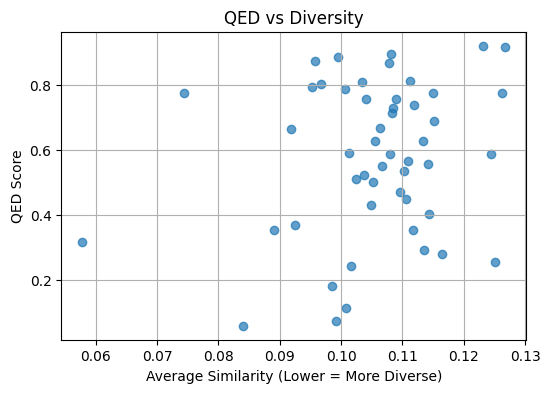

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.scatter(avg_sim_per_mol, qed_scores, alpha=0.7)

plt.xlabel("Average Similarity (Lower = More Diverse)")
plt.ylabel("QED Score")
plt.title("QED vs Diversity")

plt.grid(True)
plt.show()

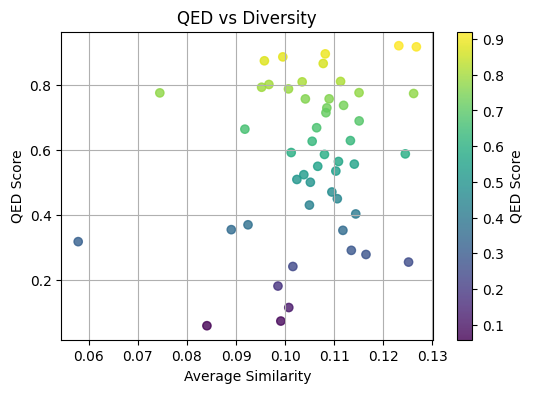

In [86]:
plt.figure(figsize=(6,4))

plt.scatter(avg_sim_per_mol, qed_scores, c=qed_scores, cmap='viridis', alpha=0.8)

plt.colorbar(label="QED Score")

plt.xlabel("Average Similarity")
plt.ylabel("QED Score")
plt.title("QED vs Diversity")

plt.grid(True)
plt.show()

In [88]:
print(len(generated_smiles))
print(len(qed_scores))
print(len(avg_sim_per_mol))

50
50
50


In [95]:
def generate_ligand_from_pocket(pocket_input):
    """
    Generate SMILES from protein pocket description
    WITHOUT forcing uniqueness (correct evaluation)
    """

    inputs = tokenizer(
        pocket_input,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=128,

            do_sample=True,
            top_p=0.95,
            top_k=50,
            temperature=1.1,
            repetition_penalty=1.2,

            num_return_sequences=5
        )

    candidates = [
        clean_smiles(
            tokenizer.decode(o, skip_special_tokens=True)
        )
        for o in outputs
    ]

    # ✅ Only validity check (NO uniqueness forcing)
    for smi in candidates:
        if smi and Chem.MolFromSmiles(smi):
            return smi

    return candidates[0] if candidates else ""


In [96]:
def evaluate_on_jsonl(dataset, num_samples=None):

    valid_count = 0
    total = 0
    qed_scores = []

    results = []

    if num_samples:
        dataset = dataset[:num_samples]

    print(f"\nEvaluating {len(dataset)} samples...\n")

    for sample in tqdm(dataset):

        input_text = sample["input"]
        true_smiles = sample["output"]

        # Generate
        gen_smiles = generate_ligand_from_pocket(input_text)

        # Validate
        mol = Chem.MolFromSmiles(gen_smiles)

        is_valid = mol is not None

        if is_valid:
            valid_count += 1
            qed_scores.append(QED.qed(mol))

        total += 1

        # Store results
        results.append({
            "input": input_text,
            "true_smiles": true_smiles,
            "generated_smiles": gen_smiles,
            "valid": is_valid
        })

        # Optional debug print
        print(f"\nGenerated: {gen_smiles}")
        print(f"Valid: {is_valid}")

    # Final metrics
    validity_rate = (valid_count / total) * 100
    avg_qed = sum(qed_scores) / len(qed_scores) if qed_scores else 0

    print("\n======================")
    print("FINAL RESULTS")
    print("======================")
    print(f"Total Samples: {total}")
    print(f"Valid Molecules: {valid_count}")
    print(f"Validity Rate: {validity_rate:.2f}%")
    print(f"Average QED: {avg_qed:.4f}")

    return results, validity_rate, avg_qed

In [97]:
results, validity, qed = evaluate_on_jsonl(dataset, num_samples=50)


Evaluating 50 samples...



  2%|▉                                           | 1/50 [00:02<02:09,  2.63s/it]


Generated: NC(=[NH2+])c1nc(Nc2ccc3cc(-c4ccc5c(c4)NC(=O)S5)ccc3c2)ns1
Valid: True


  4%|█▊                                          | 2/50 [00:05<02:08,  2.67s/it]


Generated: CN(C[C@]1(c2ccccc2)CCOCC1)S(=O)(=O)c1nn(-c2cccc(N)c2)nc1N
Valid: True


...


Generated: CC1(C)OCc2c(-n3cnc4c(N)nc(N)nc43)c(Cl)cc(NC(=O)N3CC[NH+](C)CC3)c21
Valid: True


 98%|██████████████████████████████████████████▏| 49/50 [01:56<00:02,  2.48s/it]


Generated: COc1cc(Cc2[nH]c3cc(O)c(C(=O)[O-])cc3[nH+]2)cc(OC)c1OC
Valid: True


100%|███████████████████████████████████████████| 50/50 [01:58<00:00,  2.37s/it]


Generated: CC[C@H](C)NC(=O)[C@H]1CN(c2nc3ncccc3o2)c2cccc(S(N)(=O)=O)c21
Valid: True

FINAL RESULTS
Total Samples: 50
Valid Molecules: 49
Validity Rate: 98.00%
Average QED: 0.5588


In [98]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df.to_csv("generation_results_50_epochs_unique_2.csv", index=False)

In [99]:
train_smiles = set(df["output"])
train_smiles = set(df["output"])

generated_smiles = [r["generated_smiles"] for r in results]

novel = [s for s in generated_smiles if s not in train_smiles]

print("Novel molecules:", len(novel))
print("Novelty %:", len(novel) / len(generated_smiles) * 100)
generated_smiles = [r["generated_smiles"] for r in results]

novel = [s for s in generated_smiles if s not in train_smiles]

print("Novel molecules:", len(novel))
print("Novelty %:", len(novel) / len(generated_smiles) * 100)
unique_smiles = set(generated_smiles)

print("Unique molecules:", len(unique_smiles))
print("Uniqueness %:", len(unique_smiles) / len(generated_smiles) * 100)

Novel molecules: 50
Novelty %: 100.0
Novel molecules: 50
Novelty %: 100.0
Unique molecules: 50
Uniqueness %: 100.0


In [101]:
from rdkit import Chem
from rdkit import DataStructs
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

morgan_gen = GetMorganGenerator(radius=2)

def tanimoto_similarity(s1, s2):
    m1 = Chem.MolFromSmiles(s1)
    m2 = Chem.MolFromSmiles(s2)

    if m1 and m2:
        fp1 = morgan_gen.GetFingerprint(m1)
        fp2 = morgan_gen.GetFingerprint(m2)
        return DataStructs.TanimotoSimilarity(fp1, fp2)

    return 0



sims = []
for i in range(len(generated_smiles)):
    for j in range(i+1, len(generated_smiles)):
        sims.append(tanimoto_similarity(generated_smiles[i], generated_smiles[j]))

print("Average similarity:", sum(sims)/len(sims))

[10:16:53] SMILES Parse Error: unclosed ring for input: 'CC(C)(C)O[C@H]1[C@H](c2c(S(N)(=O)=O)cc3ncn([C@@H]4OCC[N+]5CCCCC5)c31)NC21=O'
[10:16:53] SMILES Parse Error: unclosed ring for input: 'CC(C)(C)O[C@H]1[C@H](c2c(S(N)(=O)=O)cc3ncn([C@@H]4OCC[N+]5CCCCC5)c31)NC21=O'
[10:16:53] SMILES Parse Error: unclosed ring for input: 'CC(C)(C)O[C@H]1[C@H](c2c(S(N)(=O)=O)cc3ncn([C@@H]4OCC[N+]5CCCCC5)c31)NC21=O'
[10:16:53] SMILES Parse Error: unclosed ring for input: 'CC(C)(C)O[C@H]1[C@H](c2c(S(N)(=O)=O)cc3ncn([C@@H]4OCC[N+]5CCCCC5)c31)NC21=O'
[10:16:53] SMILES Parse Error: unclosed ring for input: 'CC(C)(C)O[C@H]1[C@H](c2c(S(N)(=O)=O)cc3ncn([C@@H]4OCC[N+]5CCCCC5)c31)NC21=O'
[10:16:53] SMILES Parse Error: unclosed ring for input: 'CC(C)(C)O[C@H]1[C@H](c2c(S(N)(=O)=O)cc3ncn([C@@H]4OCC[N+]5CCCCC5)c31)NC21=O'
[10:16:53] SMILES Parse Error: unclosed ring for input: 'CC(C)(C)O[C@H]1[C@H](c2c(S(N)(=O)=O)cc3ncn([C@@H]4OCC[N+]5CCCCC5)c31)NC21=O'
[10:16:53] SMILES Parse Error: unclosed ring for input: 'CC(C)

Average similarity: 0.10047070713976249


In [100]:
from rdkit.Chem import Descriptors

def lipinski(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return False
    return (
        Descriptors.MolWt(mol) < 500 and
        Descriptors.NumHDonors(mol) <= 5 and
        Descriptors.NumHAcceptors(mol) <= 10 and
        Descriptors.MolLogP(mol) < 5
    )

lipinski_pass = sum(lipinski(s) for s in generated_smiles)

print("Lipinski pass %:", lipinski_pass / len(generated_smiles) * 100)

Lipinski pass %: 80.0


[10:16:53] SMILES Parse Error: unclosed ring for input: 'CC(C)(C)O[C@H]1[C@H](c2c(S(N)(=O)=O)cc3ncn([C@@H]4OCC[N+]5CCCCC5)c31)NC21=O'


In [51]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import QED, Descriptors
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams

# =========================
# Load CSV
# =========================
file_path = "generation_results_50_epochs_unique_testing.csv"
df = pd.read_csv(file_path)

SMILES_COLUMN = "generated_smiles"  # change if needed

# =========================
# PAINS Filter Setup
# =========================
params = FilterCatalogParams()
params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
pains_catalog = FilterCatalog(params)

# =========================
# Function
# =========================
def compute_props(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return pd.Series([None]*5)

        # QED
        qed = QED.qed(mol)

        # Lipinski properties
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        h_d = Descriptors.NumHDonors(mol)
        h_a = Descriptors.NumHAcceptors(mol)

        lipinski = (
            mw <= 500 and
            logp <= 5 and
            h_d <= 5 and
            h_a <= 10
        )

        # PAINS
        pains = pains_catalog.HasMatch(mol)

        return pd.Series([qed, mw, logp, lipinski, pains])

    except:
        return pd.Series([None]*5)

# =========================
# Apply
# =========================
df[["QED", "MolWt", "LogP", "Lipinski", "PAINS"]] = df[SMILES_COLUMN].apply(compute_props)

# =========================
# Save (overwrite same file)
# =========================
df.to_csv(file_path, index=False)

print("✅ File updated with required columns only!")

# =========================
# Quick stats
# =========================
print("\n📊 Avg QED:", df["QED"].mean())
print("Lipinski Pass %:", df["Lipinski"].mean() * 100)
print("PAINS %:", df["PAINS"].mean() * 100)

[11:20:29] SMILES Parse Error: unclosed ring for input: 'CC[C@H](C)n1nc(-c2cn3c(n2)CCc2cc(=O)[nH]n2C)cc1C(N)=O'
[11:20:29] Can't kekulize mol.  Unkekulized atoms: 14 15 16 17 24


✅ File updated with required columns only!

📊 Avg QED: 0.5850199129952482
Lipinski Pass %: 86.23853211009175
PAINS %: 0.0


ValueError: 'c' argument must be a color, a sequence of colors, or a sequence of numbers, not 0      green
1        red
2      green
3      green
4      green
       ...  
106    green
107    green
108    green
109      red
110    green
Name: Lipinski, Length: 111, dtype: object

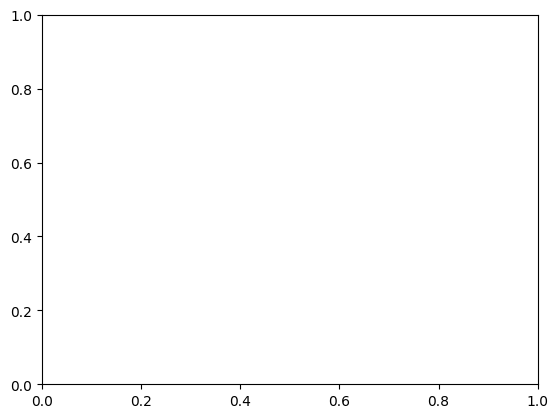

In [52]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# SETTINGS
# =========================
file_path = "generation_results_50_epochs_unique_testing.csv"

# 🔥 CHANGE THIS (or extract automatically)
PDB_NAME = "1V4"

# Output folder
output_dir = f"plots_{PDB_NAME}"
os.makedirs(output_dir, exist_ok=True)

# =========================
# LOAD DATA
# =========================
df = pd.read_csv(file_path)

# =========================
# 1️⃣ QED Distribution
# =========================
plt.figure()
plt.hist(df["QED"].dropna(), bins=10)
plt.title(f"{PDB_NAME} - QED Distribution")
plt.xlabel("QED")
plt.ylabel("Count")
plt.grid(True)

plt.savefig(f"{output_dir}/{PDB_NAME}_QED_distribution.png", dpi=300, bbox_inches='tight')
plt.close()

# =========================
# 2️⃣ Lipinski Bar
# =========================
lipinski_counts = df["Lipinski"].value_counts()

plt.figure()
plt.bar(lipinski_counts.index.astype(str), lipinski_counts.values)
plt.title(f"{PDB_NAME} - Lipinski Compliance")
plt.xlabel("Lipinski")
plt.ylabel("Count")

plt.savefig(f"{output_dir}/{PDB_NAME}_Lipinski.png", dpi=300, bbox_inches='tight')
plt.close()

# =========================
# 3️⃣ PAINS Bar
# =========================
pains_counts = df["PAINS"].value_counts()

plt.figure()
plt.bar(pains_counts.index.astype(str), pains_counts.values)
plt.title(f"{PDB_NAME} - PAINS Alerts")
plt.xlabel("PAINS")
plt.ylabel("Count")

plt.savefig(f"{output_dir}/{PDB_NAME}_PAINS.png", dpi=300, bbox_inches='tight')
plt.close()

# =========================
# 4️⃣ MolWt vs LogP
# =========================
plt.figure()
plt.scatter(df["MolWt"], df["LogP"])
plt.title(f"{PDB_NAME} - MolWt vs LogP")
plt.xlabel("MolWt")
plt.ylabel("LogP")
plt.grid(True)

plt.savefig(f"{output_dir}/{PDB_NAME}_MolWt_vs_LogP.png", dpi=300, bbox_inches='tight')
plt.close()

# =========================
# 5️⃣ QED vs LogP
# =========================
plt.figure()
plt.scatter(df["LogP"], df["QED"])
plt.title(f"{PDB_NAME} - QED vs LogP")
plt.xlabel("LogP")
plt.ylabel("QED")
plt.grid(True)

plt.savefig(f"{output_dir}/{PDB_NAME}_QED_vs_LogP.png", dpi=300, bbox_inches='tight')
plt.close()

# =========================
# 6️⃣ Box Plot
# =========================
plt.figure()
plt.boxplot([df["QED"].dropna(), df["MolWt"].dropna(), df["LogP"].dropna()])
plt.xticks([1,2,3], ["QED", "MolWt", "LogP"])
plt.title(f"{PDB_NAME} - Property Distribution")

plt.savefig(f"{output_dir}/{PDB_NAME}_Boxplot.png", dpi=300, bbox_inches='tight')
plt.close()

# =========================
# 7️⃣ Highlight Plot
# =========================
colors = df["Lipinski"].map({True: "green", False: "red"})

plt.figure()
plt.scatter(df["MolWt"], df["QED"], c=colors)
plt.title(f"{PDB_NAME} - QED vs MolWt (Lipinski Highlight)")
plt.xlabel("MolWt")
plt.ylabel("QED")

plt.savefig(f"{output_dir}/{PDB_NAME}_QED_vs_MolWt.png", dpi=300, bbox_inches='tight')
plt.close()

print(f"✅ All plots saved in folder: {output_dir}")

In [8]:
import pandas as pd

df = pd.read_json("1BCD_test_pocket_dataset.jsonl", lines=True)

print("Total samples:", len(df))
print(df.columns)

Total samples: 2
Index(['instruction', 'input', 'output'], dtype='object')


In [9]:
dataset = df.to_dict(orient="records")
len(dataset)

2

In [10]:
from rdkit import Chem
from rdkit.Chem import QED
from tqdm import tqdm

In [11]:
def generate_ligand_from_pocket(pocket_input):
    """
    Generate SMILES from protein pocket description
    WITHOUT forcing uniqueness (correct evaluation)
    """

    inputs = tokenizer(
        pocket_input,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=128,

            do_sample=True,
            top_p=0.95,
            top_k=50,
            temperature=1.1,
            repetition_penalty=1.2,

            num_return_sequences=5
        )

    candidates = [
        clean_smiles(
            tokenizer.decode(o, skip_special_tokens=True)
        )
        for o in outputs
    ]

    # ✅ Only validity check (NO uniqueness forcing)
    for smi in candidates:
        if smi and Chem.MolFromSmiles(smi):
            return smi

    return candidates[0] if candidates else ""


In [12]:
def evaluate_on_jsonl(dataset, num_samples=None):

    valid_count = 0
    total = 0
    qed_scores = []

    results = []

    if num_samples:
        dataset = dataset[:num_samples]

    print(f"\nEvaluating {len(dataset)} samples...\n")

    for sample in tqdm(dataset):

        input_text = sample["input"]
        true_smiles = sample["output"]

        # Generate
        gen_smiles = generate_ligand_from_pocket(input_text)

        # Validate
        mol = Chem.MolFromSmiles(gen_smiles)

        is_valid = mol is not None

        if is_valid:
            valid_count += 1
            qed_scores.append(QED.qed(mol))

        total += 1

        # Store results
        results.append({
            "input": input_text,
            "true_smiles": true_smiles,
            "generated_smiles": gen_smiles,
            "valid": is_valid
        })

        # Optional debug print
        print(f"\nGenerated: {gen_smiles}")
        print(f"Valid: {is_valid}")

    # Final metrics
    validity_rate = (valid_count / total) * 100
    avg_qed = sum(qed_scores) / len(qed_scores) if qed_scores else 0

    print("\n======================")
    print("FINAL RESULTS")
    print("======================")
    print(f"Total Samples: {total}")
    print(f"Valid Molecules: {valid_count}")
    print(f"Validity Rate: {validity_rate:.2f}%")
    print(f"Average QED: {avg_qed:.4f}")

    return results, validity_rate, avg_qed

In [13]:
results, validity, qed = evaluate_on_jsonl(dataset, num_samples=2)


Evaluating 2 samples...



 50%|██████████████████████▌                      | 1/2 [00:02<00:02,  2.76s/it]


Generated: O=C([O-])[C@H]1C[NH2+][C@H]2O[C@@H](n3cc(-c4cccc5nccnc45)nc32)[C@H](O)[C@@H]1O
Valid: True


100%|█████████████████████████████████████████████| 2/2 [00:04<00:00,  2.37s/it]


Generated: C[NH+](C)CCCCNC1=CC(=O)Nc2cc(Cl)cc(OC)c21
Valid: True

FINAL RESULTS
Total Samples: 2
Valid Molecules: 2
Validity Rate: 100.00%
Average QED: 0.5617


In [14]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df.to_csv("_1BCD_generation_results_50_epochs_unique_2.csv", index=False)

In [15]:
train_smiles = set(df["output"])
train_smiles = set(df["output"])

generated_smiles = [r["generated_smiles"] for r in results]

novel = [s for s in generated_smiles if s not in train_smiles]

print("Novel molecules:", len(novel))
print("Novelty %:", len(novel) / len(generated_smiles) * 100)
generated_smiles = [r["generated_smiles"] for r in results]

novel = [s for s in generated_smiles if s not in train_smiles]

print("Novel molecules:", len(novel))
print("Novelty %:", len(novel) / len(generated_smiles) * 100)
unique_smiles = set(generated_smiles)

print("Unique molecules:", len(unique_smiles))
print("Uniqueness %:", len(unique_smiles) / len(generated_smiles) * 100)

Novel molecules: 2
Novelty %: 100.0
Novel molecules: 2
Novelty %: 100.0
Unique molecules: 2
Uniqueness %: 100.0


In [16]:
from rdkit import Chem
from rdkit import DataStructs
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

morgan_gen = GetMorganGenerator(radius=2)

def tanimoto_similarity(s1, s2):
    m1 = Chem.MolFromSmiles(s1)
    m2 = Chem.MolFromSmiles(s2)

    if m1 and m2:
        fp1 = morgan_gen.GetFingerprint(m1)
        fp2 = morgan_gen.GetFingerprint(m2)
        return DataStructs.TanimotoSimilarity(fp1, fp2)

    return 0



sims = []
for i in range(len(generated_smiles)):
    for j in range(i+1, len(generated_smiles)):
        sims.append(tanimoto_similarity(generated_smiles[i], generated_smiles[j]))

print("Average similarity:", sum(sims)/len(sims))

Average similarity: 0.030303030303030304


In [17]:
from rdkit.Chem import Descriptors

def lipinski(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return False
    return (
        Descriptors.MolWt(mol) < 500 and
        Descriptors.NumHDonors(mol) <= 5 and
        Descriptors.NumHAcceptors(mol) <= 10 and
        Descriptors.MolLogP(mol) < 5
    )

lipinski_pass = sum(lipinski(s) for s in generated_smiles)

print("Lipinski pass %:", lipinski_pass / len(generated_smiles) * 100)

Lipinski pass %: 100.0


In [47]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import QED, Descriptors
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams

# =========================
# Load CSV
# =========================
file_path = "_1BCD_generation_results_50_epochs_unique_2.csv"
df = pd.read_csv(file_path)

SMILES_COLUMN = "generated_smiles"  # change if needed

# =========================
# PAINS Filter Setup
# =========================
params = FilterCatalogParams()
params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
pains_catalog = FilterCatalog(params)

# =========================
# Function
# =========================
def compute_props(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return pd.Series([None]*5)

        # QED
        qed = QED.qed(mol)

        # Lipinski properties
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        h_d = Descriptors.NumHDonors(mol)
        h_a = Descriptors.NumHAcceptors(mol)

        lipinski = (
            mw <= 500 and
            logp <= 5 and
            h_d <= 5 and
            h_a <= 10
        )

        # PAINS
        pains = pains_catalog.HasMatch(mol)

        return pd.Series([qed, mw, logp, lipinski, pains])

    except:
        return pd.Series([None]*5)

# =========================
# Apply
# =========================
df[["QED", "MolWt", "LogP", "Lipinski", "PAINS"]] = df[SMILES_COLUMN].apply(compute_props)

# =========================
# Save (overwrite same file)
# =========================
df.to_csv(file_path, index=False)

print("✅ File updated with required columns only!")

# =========================
# Quick stats
# =========================
print("\n📊 Avg QED:", df["QED"].mean())
print("Lipinski Pass %:", df["Lipinski"].mean() * 100)
print("PAINS %:", df["PAINS"].mean() * 100)

✅ File updated with required columns only!

📊 Avg QED: 0.56173488287786
Lipinski Pass %: 100.0
PAINS %: 0.0


In [18]:
import pandas as pd

df = pd.read_json("1SO0_test_pocket_dataset.jsonl", lines=True)

print("Total samples:", len(df))
print(df.columns)

Total samples: 12
Index(['instruction', 'input', 'output'], dtype='object')


In [19]:
dataset = df.to_dict(orient="records")
len(dataset)

12

In [20]:
from rdkit import Chem
from rdkit.Chem import QED
from tqdm import tqdm
def generate_ligand_from_pocket(pocket_input):
    """
    Generate SMILES from protein pocket description
    WITHOUT forcing uniqueness (correct evaluation)
    """

    inputs = tokenizer(
        pocket_input,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=128,

            do_sample=True,
            top_p=0.95,
            top_k=50,
            temperature=1.1,
            repetition_penalty=1.2,

            num_return_sequences=5
        )

    candidates = [
        clean_smiles(
            tokenizer.decode(o, skip_special_tokens=True)
        )
        for o in outputs
    ]

    # ✅ Only validity check (NO uniqueness forcing)
    for smi in candidates:
        if smi and Chem.MolFromSmiles(smi):
            return smi

    return candidates[0] if candidates else ""


In [21]:
def evaluate_on_jsonl(dataset, num_samples=None):

    valid_count = 0
    total = 0
    qed_scores = []

    results = []

    if num_samples:
        dataset = dataset[:num_samples]

    print(f"\nEvaluating {len(dataset)} samples...\n")

    for sample in tqdm(dataset):

        input_text = sample["input"]
        true_smiles = sample["output"]

        # Generate
        gen_smiles = generate_ligand_from_pocket(input_text)

        # Validate
        mol = Chem.MolFromSmiles(gen_smiles)

        is_valid = mol is not None

        if is_valid:
            valid_count += 1
            qed_scores.append(QED.qed(mol))

        total += 1

        # Store results
        results.append({
            "input": input_text,
            "true_smiles": true_smiles,
            "generated_smiles": gen_smiles,
            "valid": is_valid
        })

        # Optional debug print
        print(f"\nGenerated: {gen_smiles}")
        print(f"Valid: {is_valid}")

    # Final metrics
    validity_rate = (valid_count / total) * 100
    avg_qed = sum(qed_scores) / len(qed_scores) if qed_scores else 0

    print("\n======================")
    print("FINAL RESULTS")
    print("======================")
    print(f"Total Samples: {total}")
    print(f"Valid Molecules: {valid_count}")
    print(f"Validity Rate: {validity_rate:.2f}%")
    print(f"Average QED: {avg_qed:.4f}")

    return results, validity_rate, avg_qed

In [22]:
results, validity, qed = evaluate_on_jsonl(dataset, num_samples=12)


Evaluating 12 samples...



  8%|███▋                                        | 1/12 [00:02<00:24,  2.25s/it]


Generated: O=C([O-])CCc1cccc(C(=O)N2CC(F)(F)C2)c1
Valid: True


 17%|███████▎                                    | 2/12 [00:04<00:24,  2.44s/it]


Generated: NC(=[NH2+])NCCC[N+](CC1CC[NH+](Cc2nc3cc(F)ccc3s2)CC1)S(=O)(=O)c1cccs1
Valid: True


...


Generated: CCc1noc(C)c1C(=O)NO
Valid: True


[10:55:04] SMILES Parse Error: unclosed ring for input: 'NC(=[NH2+])Nc1ccc2cn(-c3ccc(F)c(Cl)c3)c(N3CCc4c(nsc5c(=O)[nH]cc34)n2)cc2c1'
 92%|███████████████████████████████████████▍   | 11/12 [00:24<00:02,  2.31s/it]


Generated: Cc1nn([C@H]2OC(F)(F)F)c2c1-c1cc(Cl)nn1C
Valid: True


100%|███████████████████████████████████████████| 12/12 [00:26<00:00,  2.23s/it]


Generated: COc1cc(N)nc2c1CC[NH+](CCNCc1ccc(OC(F)(F)F)cc1)C2=O
Valid: True

FINAL RESULTS
Total Samples: 12
Valid Molecules: 12
Validity Rate: 100.00%
Average QED: 0.6118


In [23]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df.to_csv("1SO0_generation_results_50_epochs_unique_2.csv", index=False)

In [24]:
train_smiles = set(df["output"])
train_smiles = set(df["output"])

generated_smiles = [r["generated_smiles"] for r in results]

novel = [s for s in generated_smiles if s not in train_smiles]

print("Novel molecules:", len(novel))
print("Novelty %:", len(novel) / len(generated_smiles) * 100)
generated_smiles = [r["generated_smiles"] for r in results]

novel = [s for s in generated_smiles if s not in train_smiles]

print("Novel molecules:", len(novel))
print("Novelty %:", len(novel) / len(generated_smiles) * 100)
unique_smiles = set(generated_smiles)

print("Unique molecules:", len(unique_smiles))
print("Uniqueness %:", len(unique_smiles) / len(generated_smiles) * 100)

Novel molecules: 12
Novelty %: 100.0
Novel molecules: 12
Novelty %: 100.0
Unique molecules: 12
Uniqueness %: 100.0


In [25]:
from rdkit import Chem
from rdkit import DataStructs
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

morgan_gen = GetMorganGenerator(radius=2)

def tanimoto_similarity(s1, s2):
    m1 = Chem.MolFromSmiles(s1)
    m2 = Chem.MolFromSmiles(s2)

    if m1 and m2:
        fp1 = morgan_gen.GetFingerprint(m1)
        fp2 = morgan_gen.GetFingerprint(m2)
        return DataStructs.TanimotoSimilarity(fp1, fp2)

    return 0



sims = []
for i in range(len(generated_smiles)):
    for j in range(i+1, len(generated_smiles)):
        sims.append(tanimoto_similarity(generated_smiles[i], generated_smiles[j]))

print("Average similarity:", sum(sims)/len(sims))

Average similarity: 0.10549771366566837


In [26]:
from rdkit.Chem import Descriptors

def lipinski(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return False
    return (
        Descriptors.MolWt(mol) < 500 and
        Descriptors.NumHDonors(mol) <= 5 and
        Descriptors.NumHAcceptors(mol) <= 10 and
        Descriptors.MolLogP(mol) < 5
    )

lipinski_pass = sum(lipinski(s) for s in generated_smiles)

print("Lipinski pass %:", lipinski_pass / len(generated_smiles) * 100)

Lipinski pass %: 83.33333333333334


In [48]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import QED, Descriptors
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams

# =========================
# Load CSV
# =========================
file_path = "1SO0_generation_results_50_epochs_unique_2.csv"
df = pd.read_csv(file_path)

SMILES_COLUMN = "generated_smiles"  # change if needed

# =========================
# PAINS Filter Setup
# =========================
params = FilterCatalogParams()
params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
pains_catalog = FilterCatalog(params)

# =========================
# Function
# =========================
def compute_props(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return pd.Series([None]*5)

        # QED
        qed = QED.qed(mol)

        # Lipinski properties
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        h_d = Descriptors.NumHDonors(mol)
        h_a = Descriptors.NumHAcceptors(mol)

        lipinski = (
            mw <= 500 and
            logp <= 5 and
            h_d <= 5 and
            h_a <= 10
        )

        # PAINS
        pains = pains_catalog.HasMatch(mol)

        return pd.Series([qed, mw, logp, lipinski, pains])

    except:
        return pd.Series([None]*5)

# =========================
# Apply
# =========================
df[["QED", "MolWt", "LogP", "Lipinski", "PAINS"]] = df[SMILES_COLUMN].apply(compute_props)

# =========================
# Save (overwrite same file)
# =========================
df.to_csv(file_path, index=False)

print("✅ File updated with required columns only!")

# =========================
# Quick stats
# =========================
print("\n📊 Avg QED:", df["QED"].mean())
print("Lipinski Pass %:", df["Lipinski"].mean() * 100)
print("PAINS %:", df["PAINS"].mean() * 100)

✅ File updated with required columns only!

📊 Avg QED: 0.6118459689105783
Lipinski Pass %: 83.33333333333334
PAINS %: 0.0


In [27]:
import pandas as pd

df = pd.read_json("1UZE_test_pocket_dataset.jsonl", lines=True)

print("Total samples:", len(df))
print(df.columns)

Total samples: 4
Index(['instruction', 'input', 'output'], dtype='object')


In [28]:
dataset = df.to_dict(orient="records")
len(dataset)

4

In [29]:
from rdkit import Chem
from rdkit.Chem import QED
from tqdm import tqdm
def generate_ligand_from_pocket(pocket_input):
    """
    Generate SMILES from protein pocket description
    WITHOUT forcing uniqueness (correct evaluation)
    """

    inputs = tokenizer(
        pocket_input,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=128,

            do_sample=True,
            top_p=0.95,
            top_k=50,
            temperature=1.1,
            repetition_penalty=1.2,

            num_return_sequences=5
        )

    candidates = [
        clean_smiles(
            tokenizer.decode(o, skip_special_tokens=True)
        )
        for o in outputs
    ]

    # ✅ Only validity check (NO uniqueness forcing)
    for smi in candidates:
        if smi and Chem.MolFromSmiles(smi):
            return smi

    return candidates[0] if candidates else ""


In [32]:
def evaluate_on_jsonl(dataset, num_samples=None):

    valid_count = 0
    total = 0
    qed_scores = []

    results = []

    if num_samples:
        dataset = dataset[:num_samples]

    print(f"\nEvaluating {len(dataset)} samples...\n")

    for sample in tqdm(dataset):

        input_text = sample["input"]
        true_smiles = sample["output"]

        # Generate
        gen_smiles = generate_ligand_from_pocket(input_text)

        # Validate
        mol = Chem.MolFromSmiles(gen_smiles)

        is_valid = mol is not None

        if is_valid:
            valid_count += 1
            qed_scores.append(QED.qed(mol))

        total += 1

        # Store results
        results.append({
            "input": input_text,
            "true_smiles": true_smiles,
            "generated_smiles": gen_smiles,
            "valid": is_valid
        })

        # Optional debug print
        print(f"\nGenerated: {gen_smiles}")
        print(f"Valid: {is_valid}")

    # Final metrics
    validity_rate = (valid_count / total) * 100
    avg_qed = sum(qed_scores) / len(qed_scores) if qed_scores else 0

    print("\n======================")
    print("FINAL RESULTS")
    print("======================")
    print(f"Total Samples: {total}")
    print(f"Valid Molecules: {valid_count}")
    print(f"Validity Rate: {validity_rate:.2f}%")
    print(f"Average QED: {avg_qed:.4f}")

    return results, validity_rate, avg_qed

In [33]:
results, validity, qed = evaluate_on_jsonl(dataset, num_samples=4)


Evaluating 4 samples...



 25%|███████████▎                                 | 1/4 [00:02<00:06,  2.12s/it]


Generated: O=C(CC[N+]1CC[NH2+]CC1)NO
Valid: True


[10:58:14] Can't kekulize mol.  Unkekulized atoms: 6 8 9 11 12 13 14 15 17
 50%|██████████████████████▌                      | 2/4 [00:04<00:05,  2.51s/it]


Generated: Cn1ccc2nc(-c3c[nH]c4ccccc34)nc(N3CCN(S(=O)(=O)C(=O)N5CCOCC5)CC3)c12
Valid: True


 75%|█████████████████████████████████▊           | 3/4 [00:06<00:02,  2.30s/it]


Generated: O=C([O-])c1ccnc2scc(-c3nsc4c3CCOC4)c12
Valid: True


100%|█████████████████████████████████████████████| 4/4 [00:09<00:00,  2.43s/it]


Generated: C[NH+]1CCN(C(=O)Nc2nc3cc(F)c(F)c(F)c3[nH]2)CC1
Valid: True

FINAL RESULTS
Total Samples: 4
Valid Molecules: 4
Validity Rate: 100.00%
Average QED: 0.5221


In [34]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df.to_csv("1UZE_generation_results_50_epochs_unique_2.csv", index=False)

In [35]:
train_smiles = set(df["output"])
train_smiles = set(df["output"])

generated_smiles = [r["generated_smiles"] for r in results]

novel = [s for s in generated_smiles if s not in train_smiles]

print("Novel molecules:", len(novel))
print("Novelty %:", len(novel) / len(generated_smiles) * 100)
generated_smiles = [r["generated_smiles"] for r in results]

novel = [s for s in generated_smiles if s not in train_smiles]

print("Novel molecules:", len(novel))
print("Novelty %:", len(novel) / len(generated_smiles) * 100)
unique_smiles = set(generated_smiles)

print("Unique molecules:", len(unique_smiles))
print("Uniqueness %:", len(unique_smiles) / len(generated_smiles) * 100)

Novel molecules: 4
Novelty %: 100.0
Novel molecules: 4
Novelty %: 100.0
Unique molecules: 4
Uniqueness %: 100.0


In [36]:
from rdkit import Chem
from rdkit import DataStructs
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

morgan_gen = GetMorganGenerator(radius=2)

def tanimoto_similarity(s1, s2):
    m1 = Chem.MolFromSmiles(s1)
    m2 = Chem.MolFromSmiles(s2)

    if m1 and m2:
        fp1 = morgan_gen.GetFingerprint(m1)
        fp2 = morgan_gen.GetFingerprint(m2)
        return DataStructs.TanimotoSimilarity(fp1, fp2)

    return 0



sims = []
for i in range(len(generated_smiles)):
    for j in range(i+1, len(generated_smiles)):
        sims.append(tanimoto_similarity(generated_smiles[i], generated_smiles[j]))

print("Average similarity:", sum(sims)/len(sims))

Average similarity: 0.0962485268764185


In [37]:
from rdkit.Chem import Descriptors

def lipinski(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return False
    return (
        Descriptors.MolWt(mol) < 500 and
        Descriptors.NumHDonors(mol) <= 5 and
        Descriptors.NumHAcceptors(mol) <= 10 and
        Descriptors.MolLogP(mol) < 5
    )

lipinski_pass = sum(lipinski(s) for s in generated_smiles)

print("Lipinski pass %:", lipinski_pass / len(generated_smiles) * 100)

Lipinski pass %: 75.0


In [49]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import QED, Descriptors
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams

# =========================
# Load CSV
# =========================
file_path = "1UZE_generation_results_50_epochs_unique_2.csv"
df = pd.read_csv(file_path)

SMILES_COLUMN = "generated_smiles"  # change if needed

# =========================
# PAINS Filter Setup
# =========================
params = FilterCatalogParams()
params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
pains_catalog = FilterCatalog(params)

# =========================
# Function
# =========================
def compute_props(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return pd.Series([None]*5)

        # QED
        qed = QED.qed(mol)

        # Lipinski properties
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        h_d = Descriptors.NumHDonors(mol)
        h_a = Descriptors.NumHAcceptors(mol)

        lipinski = (
            mw <= 500 and
            logp <= 5 and
            h_d <= 5 and
            h_a <= 10
        )

        # PAINS
        pains = pains_catalog.HasMatch(mol)

        return pd.Series([qed, mw, logp, lipinski, pains])

    except:
        return pd.Series([None]*5)

# =========================
# Apply
# =========================
df[["QED", "MolWt", "LogP", "Lipinski", "PAINS"]] = df[SMILES_COLUMN].apply(compute_props)

# =========================
# Save (overwrite same file)
# =========================
df.to_csv(file_path, index=False)

print("✅ File updated with required columns only!")

# =========================
# Quick stats
# =========================
print("\n📊 Avg QED:", df["QED"].mean())
print("Lipinski Pass %:", df["Lipinski"].mean() * 100)
print("PAINS %:", df["PAINS"].mean() * 100)

✅ File updated with required columns only!

📊 Avg QED: 0.5220756149108402
Lipinski Pass %: 75.0
PAINS %: 0.0


In [38]:
import pandas as pd

df = pd.read_json("3DHF_test_pocket_dataset.jsonl", lines=True)

print("Total samples:", len(df))
print(df.columns)

Total samples: 5
Index(['instruction', 'input', 'output'], dtype='object')


In [39]:
dataset = df.to_dict(orient="records")
len(dataset)

5

In [40]:
results, validity, qed = evaluate_on_jsonl(dataset, num_samples=5)


Evaluating 5 samples...



  0%|                                                     | 0/5 [00:00<?, ?it/s][11:00:12] Can't kekulize mol.  Unkekulized atoms: 27 28 29 30 36
[11:00:12] Can't kekulize mol.  Unkekulized atoms: 3 12 13
 20%|█████████                                    | 1/5 [00:02<00:11,  2.81s/it]


Generated: CC(C)Oc1cc2n[nH]nc2cc1Nc1ccc2nc(N3CCC(C#N)CC3)ncc2n1
Valid: True


 40%|██████████████████                           | 2/5 [00:04<00:06,  2.32s/it]


Generated: C#CC=Cc1nc(N)sc1-n1ncnc1-c1cn2[nH]c(-c3cnn(C)c3)cc2n1
Valid: True


...


Generated: CC(=O)[C@H](NC(=O)C(C)(C)c1cc(Br)cs1)C(=O)[O-]
Valid: True


 80%|████████████████████████████████████         | 4/5 [00:09<00:02,  2.23s/it]


Generated: CC(C)[N+]1CCC(Oc2ncc3c(=O)[nH]cnc3n2)CC1
Valid: True


[11:00:21] Can't kekulize mol.  Unkekulized atoms: 7 8 9 15 16 32 33 34
100%|█████████████████████████████████████████████| 5/5 [00:11<00:00,  2.32s/it]


Generated: COc1nc2[nH]c(C(=O)NCc3cn[nH]n3)cc2cn1
Valid: True

FINAL RESULTS
Total Samples: 5
Valid Molecules: 5
Validity Rate: 100.00%
Average QED: 0.6368


In [41]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df.to_csv("3DHF_generation_results_50_epochs_unique_2.csv", index=False)

In [42]:
train_smiles = set(df["output"])
train_smiles = set(df["output"])

generated_smiles = [r["generated_smiles"] for r in results]

novel = [s for s in generated_smiles if s not in train_smiles]

print("Novel molecules:", len(novel))
print("Novelty %:", len(novel) / len(generated_smiles) * 100)
generated_smiles = [r["generated_smiles"] for r in results]

novel = [s for s in generated_smiles if s not in train_smiles]

print("Novel molecules:", len(novel))
print("Novelty %:", len(novel) / len(generated_smiles) * 100)
unique_smiles = set(generated_smiles)

print("Unique molecules:", len(unique_smiles))
print("Uniqueness %:", len(unique_smiles) / len(generated_smiles) * 100)

Novel molecules: 5
Novelty %: 100.0
Novel molecules: 5
Novelty %: 100.0
Unique molecules: 5
Uniqueness %: 100.0


In [43]:
from rdkit import Chem
from rdkit import DataStructs
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

morgan_gen = GetMorganGenerator(radius=2)

def tanimoto_similarity(s1, s2):
    m1 = Chem.MolFromSmiles(s1)
    m2 = Chem.MolFromSmiles(s2)

    if m1 and m2:
        fp1 = morgan_gen.GetFingerprint(m1)
        fp2 = morgan_gen.GetFingerprint(m2)
        return DataStructs.TanimotoSimilarity(fp1, fp2)

    return 0



sims = []
for i in range(len(generated_smiles)):
    for j in range(i+1, len(generated_smiles)):
        sims.append(tanimoto_similarity(generated_smiles[i], generated_smiles[j]))

print("Average similarity:", sum(sims)/len(sims))

Average similarity: 0.11040933873491485


In [44]:
from rdkit.Chem import Descriptors

def lipinski(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return False
    return (
        Descriptors.MolWt(mol) < 500 and
        Descriptors.NumHDonors(mol) <= 5 and
        Descriptors.NumHAcceptors(mol) <= 10 and
        Descriptors.MolLogP(mol) < 5
    )

lipinski_pass = sum(lipinski(s) for s in generated_smiles)

print("Lipinski pass %:", lipinski_pass / len(generated_smiles) * 100)

Lipinski pass %: 100.0


In [55]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import QED, Descriptors
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams

# =========================
# Load CSV
# =========================
file_path = "generation_results_50_epochs_unique_2.csv"
df = pd.read_csv(file_path)

SMILES_COLUMN = "generated_smiles"  # change if needed

# =========================
# PAINS Filter Setup
# =========================
params = FilterCatalogParams()
params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
pains_catalog = FilterCatalog(params)

# =========================
# Function
# =========================
def compute_props(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return pd.Series([None]*5)

        # QED
        qed = QED.qed(mol)

        # Lipinski properties
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        h_d = Descriptors.NumHDonors(mol)
        h_a = Descriptors.NumHAcceptors(mol)

        lipinski = (
            mw <= 500 and
            logp <= 5 and
            h_d <= 5 and
            h_a <= 10
        )

        # PAINS
        pains = pains_catalog.HasMatch(mol)

        return pd.Series([qed, mw, logp, lipinski, pains])

    except:
        return pd.Series([None]*5)

# =========================
# Apply
# =========================
df[["QED", "MolWt", "LogP", "Lipinski", "PAINS"]] = df[SMILES_COLUMN].apply(compute_props)

# =========================
# Save (overwrite same file)
# =========================
df.to_csv(file_path, index=False)

print("✅ File updated with required columns only!")

# =========================
# Quick stats
# =========================
print("\n📊 Avg QED:", df["QED"].mean())
print("Lipinski Pass %:", df["Lipinski"].mean() * 100)
print("PAINS %:", df["PAINS"].mean() * 100)

✅ File updated with required columns only!

📊 Avg QED: 0.5588182711295258
Lipinski Pass %: 81.63265306122449
PAINS %: 0.0


[14:53:31] SMILES Parse Error: unclosed ring for input: 'CC(C)(C)O[C@H]1[C@H](c2c(S(N)(=O)=O)cc3ncn([C@@H]4OCC[N+]5CCCCC5)c31)NC21=O'


In [53]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# SETTINGS
# =========================
file_path = "3DHF_generation_results_50_epochs_unique_2.csv"
# 🔥 CHANGE THIS (or extract automatically)
PDB_NAME = "3DHF"

# Output folder
output_dir = f"plots_{PDB_NAME}"
os.makedirs(output_dir, exist_ok=True)

# =========================
# LOAD DATA
# =========================
df = pd.read_csv(file_path)

# =========================
# 1️⃣ QED Distribution
# =========================
plt.figure()
plt.hist(df["QED"].dropna(), bins=10)
plt.title(f"{PDB_NAME} - QED Distribution")
plt.xlabel("QED")
plt.ylabel("Count")
plt.grid(True)

plt.savefig(f"{output_dir}/{PDB_NAME}_QED_distribution.png", dpi=300, bbox_inches='tight')
plt.close()

# =========================
# 2️⃣ Lipinski Bar
# =========================
lipinski_counts = df["Lipinski"].value_counts()

plt.figure()
plt.bar(lipinski_counts.index.astype(str), lipinski_counts.values)
plt.title(f"{PDB_NAME} - Lipinski Compliance")
plt.xlabel("Lipinski")
plt.ylabel("Count")

plt.savefig(f"{output_dir}/{PDB_NAME}_Lipinski.png", dpi=300, bbox_inches='tight')
plt.close()

# =========================
# 3️⃣ PAINS Bar
# =========================
pains_counts = df["PAINS"].value_counts()

plt.figure()
plt.bar(pains_counts.index.astype(str), pains_counts.values)
plt.title(f"{PDB_NAME} - PAINS Alerts")
plt.xlabel("PAINS")
plt.ylabel("Count")

plt.savefig(f"{output_dir}/{PDB_NAME}_PAINS.png", dpi=300, bbox_inches='tight')
plt.close()

# =========================
# 4️⃣ MolWt vs LogP
# =========================
plt.figure()
plt.scatter(df["MolWt"], df["LogP"])
plt.title(f"{PDB_NAME} - MolWt vs LogP")
plt.xlabel("MolWt")
plt.ylabel("LogP")
plt.grid(True)

plt.savefig(f"{output_dir}/{PDB_NAME}_MolWt_vs_LogP.png", dpi=300, bbox_inches='tight')
plt.close()

# =========================
# 5️⃣ QED vs LogP
# =========================
plt.figure()
plt.scatter(df["LogP"], df["QED"])
plt.title(f"{PDB_NAME} - QED vs LogP")
plt.xlabel("LogP")
plt.ylabel("QED")
plt.grid(True)

plt.savefig(f"{output_dir}/{PDB_NAME}_QED_vs_LogP.png", dpi=300, bbox_inches='tight')
plt.close()

# =========================
# 6️⃣ Box Plot
# =========================
plt.figure()
plt.boxplot([df["QED"].dropna(), df["MolWt"].dropna(), df["LogP"].dropna()])
plt.xticks([1,2,3], ["QED", "MolWt", "LogP"])
plt.title(f"{PDB_NAME} - Property Distribution")

plt.savefig(f"{output_dir}/{PDB_NAME}_Boxplot.png", dpi=300, bbox_inches='tight')
plt.close()

# =========================
# 7️⃣ Highlight Plot
# =========================
colors = df["Lipinski"].map({True: "green", False: "red"})

plt.figure()
plt.scatter(df["MolWt"], df["QED"], c=colors)
plt.title(f"{PDB_NAME} - QED vs MolWt (Lipinski Highlight)")
plt.xlabel("MolWt")
plt.ylabel("QED")

plt.savefig(f"{output_dir}/{PDB_NAME}_QED_vs_MolWt.png", dpi=300, bbox_inches='tight')
plt.close()

print(f"✅ All plots saved in folder: {output_dir}")

✅ All plots saved in folder: plots_3DHF
